In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import signal as sg
import time
import os
import itertools
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.spatial import cKDTree
import cartopy.feature as cfeature
from sklearn.cluster import DBSCAN
from scipy.integrate import cumtrapz
import metpy.calc as mpcalc
from scipy import interpolate
from matplotlib import patches

In [2]:
# os computer name
os.environ['COMPUTERNAME']

'DESKTOP-EQAO3M5'

In [3]:
if os.environ['COMPUTERNAME'] == 'DESKTOP-EQAO3M5':
    path = 'F:\\github\\vortex-remove\\src\\data\\'
else:
    path = 'H:\\github\\vortex-remove\\src\\data\\'

In [4]:
# path = 'f:\\git\\github\\vortex-remove\\vortex-remove\\src\\'
lat_range = (30,12) 
lon_range = (107, 128)
# path = 'H:\\github\\vortex-remove\\src\\data\\'
inputFileName = os.path.join(path, '2018_9_16_UV.nc')
gridUnit = 0.25
ds = xr.open_dataset(inputFileName)

In [5]:
v10 = ds['v10'][0,:,:].sel(latitude=slice(*lat_range), longitude=slice(*lon_range)).sortby('latitude')
u10 = ds['u10'][0,:,:].sel(latitude=slice(*lat_range), longitude=slice(*lon_range)).sortby('latitude')
latitude = v10.latitude
longitude = v10.longitude
print(u10)

<xarray.DataArray 'u10' (latitude: 73, longitude: 85)>
[6205 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 107.0 107.2 107.5 107.8 ... 127.5 127.8 128.0
  * latitude   (latitude) float32 12.0 12.25 12.5 12.75 ... 29.5 29.75 30.0
    time       datetime64[ns] 2018-09-16
Attributes:
    units:      m s**-1
    long_name:  10 metre U wind component


The location where speed_section first drops below 17 with decreasing gradient is at distance 218.47619047619048km
The location where speed_section first drops below 12 with decreasing gradient is at distance 232.57142857142856km
The maximum value of u10_section is at distance 140.95238095238085, max speed is <xarray.DataArray ()>
array(28.57805205)
Coordinates:
    time     datetime64[ns] 2018-09-16
R_min267.8095238095236


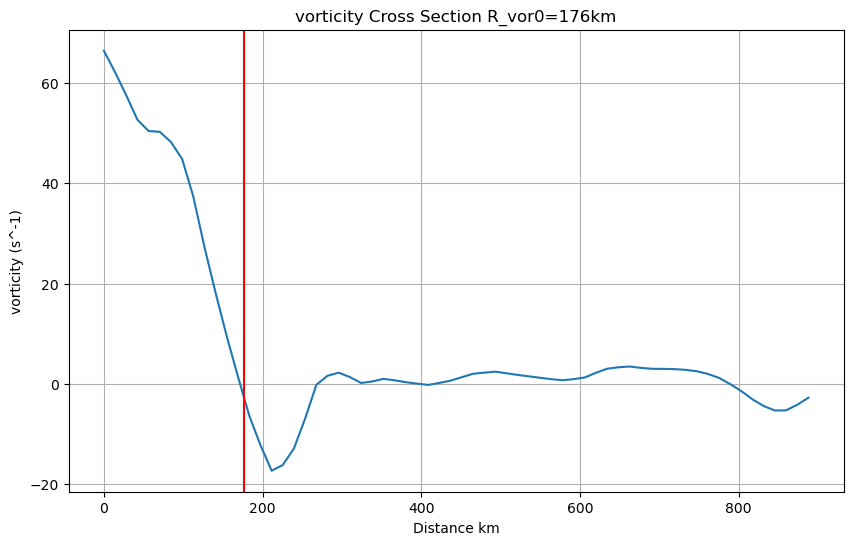

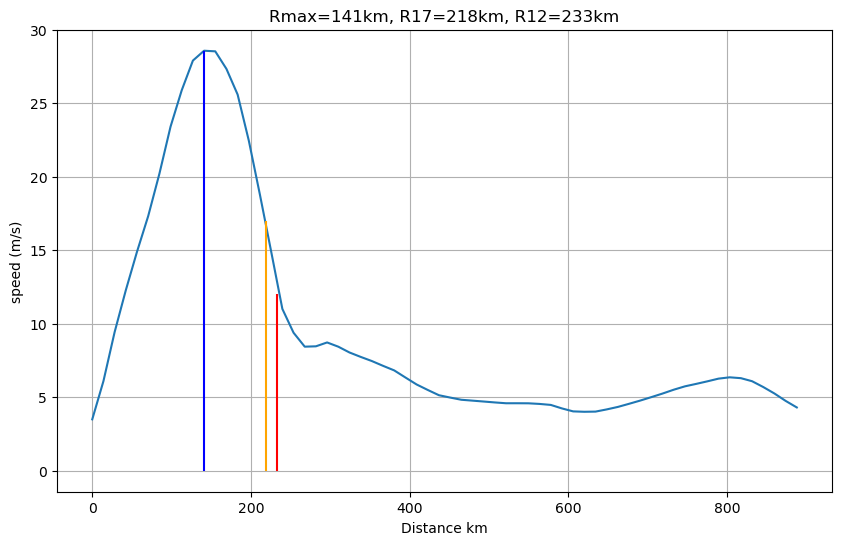

In [56]:
# ================从中心点开始插值==================#
# Define the points
p0 = [20.8125, 115.125]
p1 = [28.8125, 115.125]#[p0[0], p0[1]+8]

# Number of cross section points
n_points = int(np.sqrt((p1[1]-p0[1])**2 + (p1[0]-p0[0])**2)/gridUnit)*2

# Create a set of points along the path
lon_along_path = np.linspace(p0[1], p1[1], n_points)
lat_along_path = np.linspace(p0[0], p1[0], n_points)

# Create a new dataset with these coordinates
new_coords = xr.Dataset({"longitude": (["points"], lon_along_path), "latitude": (["points"], lat_along_path)})

# ================计算速度阈值==================#
# Perform the interpolation along the path
u10_section = u10.interp(new_coords)
v10_section = v10.interp(new_coords)
speed_section = np.sqrt(u10_section**2 + v10_section**2)
# Create a distance array along the path
distance_along_path = np.sqrt(np.diff(lon_along_path)**2 + np.diff(lat_along_path)**2)
distance_along_path = np.insert(distance_along_path, 0, 0)  # insert 0 at the start
cumulative_distance = np.cumsum(distance_along_path)
cumulative_distance = cumulative_distance*111. # 纬度距离换算成公里

# Compute the gradient of u10_section
gradient_speed = np.gradient(speed_section)

# Initialize d_r12 as None, this will hold the distance if we find a suitable location
d_r12 = None
d_r17 = None

# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section.values[i] < 17 and gradient_speed[i]<0:
        d_r17 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        break
# Print the found location
if d_r17 is not None:
    print(f"The location where speed_section first drops below 17 with decreasing gradient is at distance {d_r17}km")
else:
    print("No such location found")

# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section.values[i] < 12 and gradient_speed[i]<0:
        d_r12 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        break

# Print the found location
if d_r12 is not None:
    print(f"The location where speed_section first drops below 12 with decreasing gradient is at distance {d_r12}km")
else:
    print("No such location found")

# Find the index of the maximum value
max_index = np.argmax(speed_section.values)

# Find the distance corresponding to this index
R_max = cumulative_distance[max_index]

# Print the result
print(f"The maximum value of u10_section is at distance {R_max}, max speed is {np.max(speed_section)}")

# ==============计算R_max 之后的极小值点==================#
R_min = cumulative_distance[-1]
R_min_index = -1
for i in range(max_index+1, len(speed_section.values)-1):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section[i-1]>speed_section[i] and speed_section[i+1]>speed_section[i]:
        R_min = cumulative_distance[i]
        R_min_index = i
        break
print(f'R_min{R_min}')

# ================计算涡度阈值==================#
vorticity = mpcalc.vorticity(u10, v10)* 1e5
vor_section = vorticity.interp(new_coords)

d_vor0 = None
# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if vor_section.values[i] < 0:
        d_vor0 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        break

plt.figure(figsize=(10,6))
plt.plot(cumulative_distance, vor_section.values)
plt.axvline(x = d_vor0,  color ='red')
plt.xlabel('Distance km')
plt.ylabel('vorticity (s^-1)')
plt.title(f'vorticity Cross Section R_vor0={d_vor0:.0f}km')
plt.grid(True)
plt.show()

# ================绘图==================#
# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative_distance, speed_section.values)
# plt.plot(cumulative_distance*111.1, gradient_speed)
plt.vlines(d_r17, 0, 17, colors='orange', linestyles='solid',)
plt.vlines(d_r12, 0, 12, colors='red', linestyles='solid',)
plt.vlines(R_max, 0, speed_section[max_index], colors='blue', linestyles='solid',)
plt.xlabel('Distance km')
plt.ylabel('speed (m/s)')
# plt.title(f'wind speed Cross Section between p0 and p1')
plt.title(f'Rmax={R_max:.0f}km, R17={d_r17:.0f}km, R12={d_r12:.0f}km')
plt.grid(True)
plt.show()




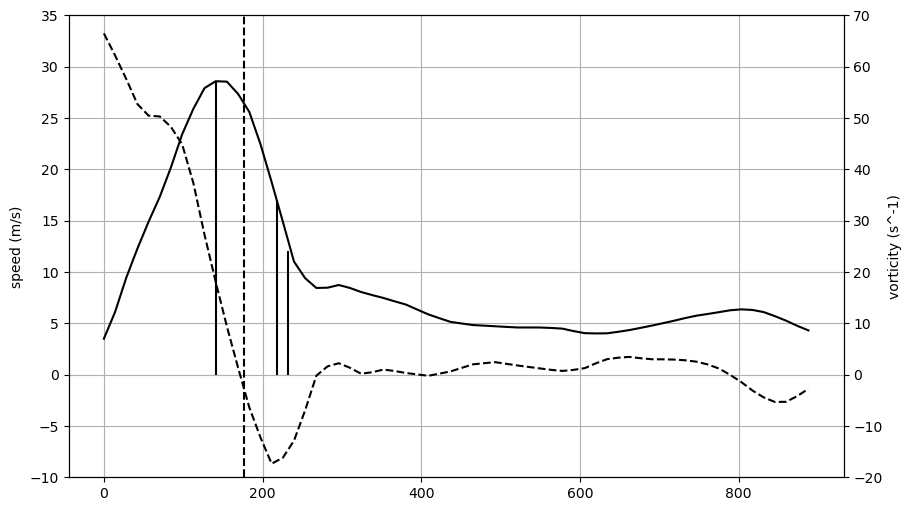

In [7]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot wind speed
ax1.plot(cumulative_distance, speed_section.values, 'k-')
ax1.vlines(d_r17, 0, 17, colors='k', linestyles='solid',)
ax1.vlines(d_r12, 0, 12, colors='k', linestyles='solid',)
ax1.vlines(R_max, 0, speed_section[max_index], colors='k', linestyles='solid',)
ax1.set_ylabel('speed (m/s)', color='k')
for tl in ax1.get_yticklabels():
    tl.set_color('k')
ax1.set_ylim(-10, 35)  # set the y-axis range

# Create a second y-axis that shares the x-axis
ax2 = ax1.twinx()

# Plot vorticity
ax2.plot(cumulative_distance, vor_section.values, 'k--')  # set line to dashed
ax2.axvline(x = d_vor0,  color ='k', linestyle='--')  # set line to dashed
ax2.set_xlabel('Distance km')
ax2.set_ylabel('vorticity (s^-1)', color='k')
# ax2.set_title(f'vorticity Cross Section R_vor0={d_vor0:.0f}km / wind speed Cross Section Rmax={R_max:.0f}km, R17={d_r17:.0f}km, R12={d_r12:.0f}km')
for tl in ax2.get_yticklabels():
    tl.set_color('k')
ax2.set_ylim(-20, 70)  # set the y-axis range

ax1.grid(True)
plt.savefig('径向距离vs风速和涡度.pdf', format='pdf')
plt.show()



In [8]:
def get_tc_info(line=[]):
    # ================从中心点开始插值==================#
    # Define the points
    p0 = line[0] # [20.8125, 115.125]
    p1 = line[1] # [p0[0], p0[1]+8]

    # Number of cross section points
    n_points = int(np.sqrt((p1[1]-p0[1])**2 + (p1[0]-p0[0])**2)/gridUnit)*2

    # Create a set of points along the path
    lon_along_path = np.linspace(p0[1], p1[1], n_points)
    lat_along_path = np.linspace(p0[0], p1[0], n_points)

    # Create a new dataset with these coordinates
    new_coords = xr.Dataset({"longitude": (["points"], lon_along_path), "latitude": (["points"], lat_along_path)})

    # ================计算速度阈值==================#
    # Perform the interpolation along the path
    u10_section = u10.interp(new_coords)
    v10_section = v10.interp(new_coords)
    speed_section = np.sqrt(u10_section**2 + v10_section**2)
    # Create a distance array along the path
    distance_along_path = np.sqrt(np.diff(lon_along_path)**2 + np.diff(lat_along_path)**2)
    distance_along_path = np.insert(distance_along_path, 0, 0)  # insert 0 at the start
    cumulative_distance = np.cumsum(distance_along_path)
    cumulative_distance = cumulative_distance*111. # 纬度距离换算成公里

    # Compute the gradient of u10_section
    gradient_speed = np.gradient(speed_section)

    # Initialize d_r12 as None, this will hold the distance if we find a suitable location
    d_r12 = None
    d_r17 = None

    # Iterate over the speed_section
    for i in range(1, len(speed_section.values)):
        # Check if the value is less than 17 and the gradient is decreasing
        if speed_section.values[i-1] >= 17 and speed_section.values[i]<=17:
        # if speed_section.values[i] < 17 and gradient_speed[i]<0:
            d_r17 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            break
    # Print the found location
    if d_r17 is not None:
        print(f"The location where speed_section first drops below 17 with decreasing gradient is at distance {d_r17}km")
    else:
        print("No such location found")

    # Iterate over the speed_section
    for i in range(1, len(speed_section.values)):
        # Check if the value is less than 12 and the gradient is decreasing
        # TODO bug 需要检查i-1大于12，i小于12
        if speed_section.values[i-1] >= 12 and speed_section.values[i]<=12:
        # if speed_section.values[i-1] < 12 and gradient_speed[i]<0:
            d_r12 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            break

    # Print the found location
    if d_r12 is not None:
        print(f"The location where speed_section first drops below 12 with decreasing gradient is at distance {d_r12}km")
    else:
        print("No such location found")

    # TODO 最大风速在d_vor0内寻找
    # Find the index of the maximum value
    max_index = np.argmax(speed_section.values)

    # Find the distance corresponding to this index
    R_max = cumulative_distance[max_index]

    # Print the result
    print(f"The maximum value of u10_section is at distance {R_max}")


    # ================计算涡度阈值==================#
    vorticity = mpcalc.vorticity(u10, v10)* 1e5
    vor_section = vorticity.interp(new_coords)

    d_vor0 = cumulative_distance[-1]
    # Iterate over the speed_section
    for i in range(1, len(speed_section.values)):
        # Check if the value is less than 12 and the gradient is decreasing
        if vor_section.values[i] < 0:
            d_vor0 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            break

    return [d_r12, d_r17, d_vor0, R_max]

In [38]:
def get_tc_info(line=[]):
    # ================从中心点开始插值==================#
    # Define the points
    p0 = line[0] # [20.8125, 115.125]
    p1 = line[1] # [p0[0], p0[1]+8]

    # Number of cross section points
    n_points = int(np.sqrt((p1[1]-p0[1])**2 + (p1[0]-p0[0])**2)/gridUnit)*8

    # Create a set of points along the path
    lon_along_path = np.linspace(p0[1], p1[1], n_points)
    lat_along_path = np.linspace(p0[0], p1[0], n_points)

    # Create a new dataset with these coordinates
    new_coords = xr.Dataset({"longitude": (["points"], lon_along_path), "latitude": (["points"], lat_along_path)})
    # ================计算速度剖面==================#
    u10_section = u10.interp(new_coords)
    v10_section = v10.interp(new_coords)
    speed_section = np.sqrt(u10_section**2 + v10_section**2)
    # Create a distance array along the path
    distance_along_path = np.sqrt(np.diff(lon_along_path)**2 + np.diff(lat_along_path)**2)
    distance_along_path = np.insert(distance_along_path, 0, 0)  # insert 0 at the start
    cumulative_distance = np.cumsum(distance_along_path)
    cumulative_distance = cumulative_distance*111. # 纬度距离换算成公里

    # Compute the gradient of u10_section
    gradient_speed = np.gradient(speed_section)

    # ================计算涡度阈值==================#
    vorticity = mpcalc.vorticity(u10, v10)* 1e5
    vor_section = vorticity.interp(new_coords)

    d_vor0 = cumulative_distance[-1]
    d_vor0_index = -1
    # Iterate over the speed_section
    for i in range(1, len(speed_section.values)):
        # Check if the value is less than 12 and the gradient is decreasing
        if vor_section.values[i] < 0:
            d_vor0 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            d_vor0_index = i
            break
# ================计算速度最大阈值==================#
    # Find the index of the maximum value
    max_index = np.argmax(speed_section[:d_vor0_index].values)

    # Find the distance corresponding to this index
    R_max = cumulative_distance[max_index]

    # Print the result
    print(f"The maximum value of u10_section is at distance {R_max}")
# ==============计算R_max 之后的极小值点==================#
    R_min = cumulative_distance[-1]
    R_min_index = -1
    for i in range(max_index+1, len(speed_section.values)-1):
        # Check if the value is less than 12 and the gradient is decreasing
        if speed_section[i-1]>speed_section[i] and speed_section[i+1]>speed_section[i]:
            R_min = cumulative_distance[i]
            R_min_index = i
            break 
    # ================计算速度阈值==================#
    # Perform the interpolation along the path

    # Initialize d_r12 as None, this will hold the distance if we find a suitable location
    d_r12 = None
    d_r17 = None

    # Iterate over the speed_section
    for i in range(max_index, len(speed_section[:R_min_index].values)):
        # Check if the value is less than 17 and the gradient is decreasing
        if speed_section.values[i-1] >= 17 and speed_section.values[i]<=17:
        # if speed_section.values[i] < 17 and gradient_speed[i]<0:
            d_r17 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            break
    # Print the found location
    if d_r17 is not None:
        print(f"The location where speed_section first drops below 17 with decreasing gradient is at distance {d_r17}km")
    else:
        print("No such location found d_r17")

    # Iterate over the speed_section
    for i in range(max_index, len(speed_section[:R_min_index].values)):
        # Check if the value is less than 12 and the gradient is decreasing
        # TODO bug 需要检查i-1大于12，i小于12
        if speed_section.values[i-1] >= 12 and speed_section.values[i]<=12:
        # if speed_section.values[i-1] < 12 and gradient_speed[i]<0:
            d_r12 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
            break

    # Print the found location
    if d_r12 is not None:
        print(f"The location where speed_section first drops below 12 with decreasing gradient is at distance {d_r12}km")
    else:
        print("No such location found d_r12")
    # ================判断边界范围==================#
    if d_r12:
        d_bound = d_r12
    else:
        if d_vor0 < R_min:
            d_bound = R_min
        else:
            d_bound = d_vor0

    return [d_bound, d_r12, d_r17, d_vor0, R_max, R_min]

In [36]:
center = [20.8125, 115.125]
def create_point_list(center=[20.8125, 115.125], delta=8):
    p0 = center
    point_list = []
    delta_root = delta/np.sqrt(2)
    p1 = [center[0], center[1]+delta] # E
    p2 = [center[0], center[1]-delta] # W
    p3 = [center[0]+delta, center[1]] # N
    p4 = [center[0]-delta, center[1]] # S
    px1 = [center[0]+delta_root, center[1]+delta_root] # NE
    px2 = [center[0]-delta_root, center[1]+delta_root] # SE
    px3 = [center[0]-delta_root, center[1]-delta_root] # SW
    px4 = [center[0]+delta_root, center[1]-delta_root] # NW
    point_list = [[p0, p1], [p0, p2], [p0, p3], [p0, p4], [p0, px1], [p0, px2], [p0, px3], [p0, px4], ]
    return point_list

point_list = create_point_list(center, 8)
print(point_list)
# 第一象限 N + NE*2 + E -> p1 + px1*2 + p3
# 第二象限 E + SE*2 + S -> p3 + px2*2 + p2
# 第三象限 S + SW*2 + W -> p2 + px3*2 + p4
# 第四象限 W + NW*2 + N -> p4 + px4*2 + p1

[[[20.8125, 115.125], [20.8125, 123.125]], [[20.8125, 115.125], [20.8125, 107.125]], [[20.8125, 115.125], [28.8125, 115.125]], [[20.8125, 115.125], [12.8125, 115.125]], [[20.8125, 115.125], [26.46935424949238, 120.78185424949238]], [[20.8125, 115.125], [15.15564575050762, 120.78185424949238]], [[20.8125, 115.125], [15.15564575050762, 109.46814575050762]], [[20.8125, 115.125], [26.46935424949238, 109.46814575050762]]]


In [39]:
# 循环point_list
tc_info_list = []
for line in point_list:
    # print(line)
    d_bound, d_r12, d_r17, d_vor0, R_max, R_min = get_tc_info(line)
    tc_info_list.append([d_bound, d_r12, d_r17, d_vor0, R_max, R_min])
print(tc_info_list)

The maximum value of u10_section is at distance 177.59999999999937
The location where speed_section first drops below 17 with decreasing gradient is at distance 454.44705882352935km
The location where speed_section first drops below 12 with decreasing gradient is at distance 527.576470588235km
The maximum value of u10_section is at distance 97.50588235294083
The location where speed_section first drops below 17 with decreasing gradient is at distance 245.50588235294188km
The location where speed_section first drops below 12 with decreasing gradient is at distance 318.6352941176475km
The maximum value of u10_section is at distance 132.3294117647058
The location where speed_section first drops below 17 with decreasing gradient is at distance 217.64705882352945km
The location where speed_section first drops below 12 with decreasing gradient is at distance 235.0588235294117km
The maximum value of u10_section is at distance 114.91764705882352
The location where speed_section first drops bel

In [40]:
tc_info = np.array(tc_info_list)

# d_r12, d_r17, d_vor0, R_max
tc_info

array([[527.576470588235, 527.576470588235, 454.44705882352935,
        356.9411764705885, 177.59999999999937, 623.3411764705876],
       [318.6352941176475, 318.6352941176475, 245.50588235294188,
        214.16470588235217, 97.50588235294083, 459.6705882352941],
       [235.0588235294117, 235.0588235294117, 217.64705882352945,
        172.37647058823546, 132.3294117647058, 271.62352941176454],
       [548.4705882352941, 548.4705882352941, 287.2941176470588,
        753.929411764706, 114.91764705882352, 839.2470588235294],
       [471.85882352941223, 471.85882352941223, 395.24705882352947,
        450.9647058823534, 149.74117647058873, 518.8705882352953],
       [642.4941176470611, None, None, 642.4941176470611,
        135.8117647058827, 198.49411764705903],
       [374.35294117647084, None, 221.1294117647059, 374.35294117647084,
        90.5411764705884, 334.30588235294164],
       [255.95294117647057, 255.95294117647057, 207.1999999999999,
        238.54117647058797, 107.95294117647

In [41]:
# 计算矩形区域
def calBound(tc_info, center=[20.8125, 115.125]):
    loc_E = [center[0], center[1] + (tc_info[0, 0]/111.0)]
    loc_W = [center[0], center[1] - (tc_info[1, 0]/111.0)]
    loc_N = [center[0] + (tc_info[2, 0]/111.0), center[1]]
    loc_S = [center[0] - (tc_info[3, 0]/111.0), center[1]]
    loc_NE = [center[0] + (tc_info[4, 0]/111.0/np.sqrt(2)), center[1] + (tc_info[4, 0]/111.0/np.sqrt(2))]
    loc_SE = [center[0] - (tc_info[5, 0]/111.0/np.sqrt(2)), center[1] + (tc_info[5, 0]/111.0/np.sqrt(2))]
    loc_SW = [center[0] - (tc_info[6, 0]/111.0/np.sqrt(2)), center[1] - (tc_info[6, 0]/111.0/np.sqrt(2))]
    loc_NW = [center[0] + (tc_info[7, 0]/111.0/np.sqrt(2)), center[1] - (tc_info[7, 0]/111.0/np.sqrt(2))]
    bound_N = np.max([loc_N[0], loc_NE[0], loc_NW[0]])
    bound_S = np.min([loc_S[0], loc_SE[0], loc_SW[0]])
    bound_E = np.max([loc_E[1], loc_NE[1], loc_SE[1]])
    bound_W = np.min([loc_W[1], loc_NW[1], loc_SW[1]])
    return [bound_N, bound_S, bound_E, bound_W, loc_N, loc_S, loc_E, loc_W, loc_NE, loc_SE, loc_SW, loc_NW]

In [42]:
bound_01 = calBound(tc_info, [20.8125, 115.125])
print(bound_01)

[23.81839706198517, 15.871323529411764, 119.87794117647059, 112.25441176470588, [22.93014705882353, 115.125], [15.871323529411764, 115.125], [20.8125, 119.87794117647059], [20.8125, 112.25441176470588], [23.81839706198517, 118.13089706198517], [16.719599572426088, 119.21790042757391], [18.42774771835125, 112.74024771835126], [22.443005048383096, 113.4944949516169]]


In [ ]:
# 滤波，涡度判别大概范围
# 判断多个中心是否为独立中心
# 非独立中心则判断最大风速距离，距离近的为真实中心
# 清除虚假中心：1. 周围风速判断，2. 周围涡度判断

In [ ]:
# 1.计算切变中心
# 2.计算切变中心周围最大风速，小于阈值剔除掉相关中心
# 3.计算切变中心周围涡度，小于阈值剔除掉相关中心
# 4.计算各中心点之间的距离，距离超过阈值的则保留
# 5.距离不满足需求的，使用反距离权重法进行计算

In [14]:
# 1. 通过u10计算风速从南到北由正值转变为负值所对应的位置(dataArray的latitude从北到南排列）
sign_change_u = np.diff(np.sign(u10), axis=0) 
shear_u_index = np.where(sign_change_u < 0) # 这将会返回latitude, longitude的索引位置，
# 2. 通过v10计算风速从西到东由负值转变为正值所对应的位置
sign_change_v = np.diff(np.sign(v10), axis=1) 
shear_v_index = np.where(sign_change_v > 0) # 这将会返回latitude, longitude的索引位置
# 根据索引值从经纬度数组中获取切变位置
shear_u_latitude = latitude[shear_u_index[0]] + gridUnit/2.0 # 由于diff函数会使得数组纬度维长度减一，因此需要减去gridUnit/2.0
shear_u_longitude = longitude[shear_u_index[1]]
shear_u = np.vstack([shear_u_latitude, shear_u_longitude]).T  # 垂直堆叠并转置，使每一行代表一个点的[latitude, longitude]

shear_v_latitude = latitude[shear_v_index[0]]
shear_v_longitude = longitude[shear_v_index[1]] + gridUnit/2.0 # 由于diff函数会使得数组经度维长度减一，因此需要加上gridUnit/2.0
shear_v = np.vstack([shear_v_latitude, shear_v_longitude]).T  # 垂直堆叠并转置，使每一行代表一个点的[latitude, longitude]


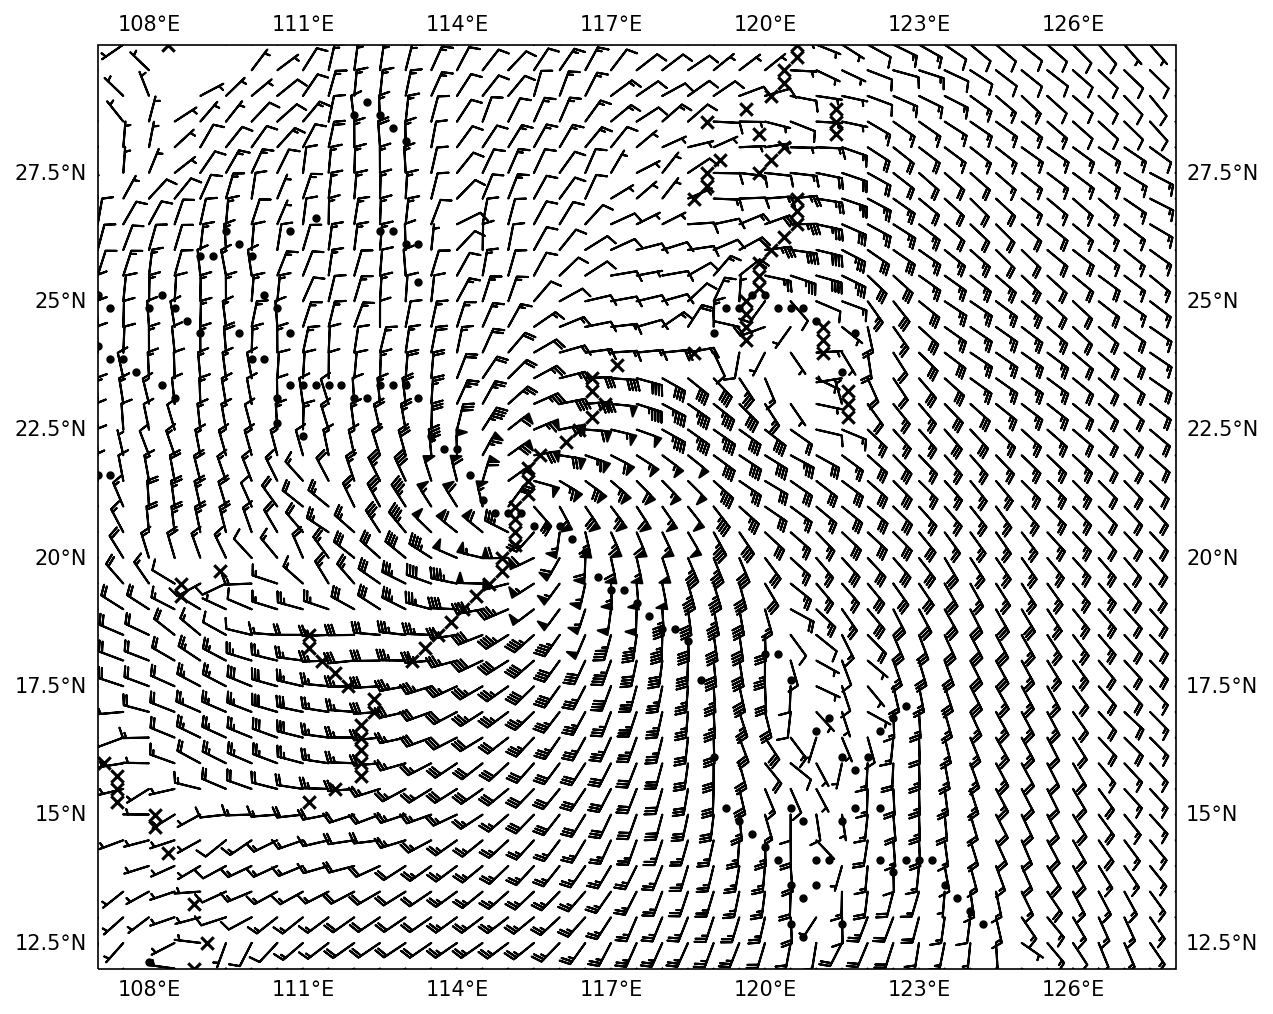

In [15]:
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]]) # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':') # 设置

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
# ax.scatter(shear_u[:, 1], shear_u[:, 0], color='r', label='Shear U', transform=ccrs.PlateCarree(),marker="_") # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
# ax.scatter(shear_v[:, 1], shear_v[:, 0], color='b', label='Shear V', transform=ccrs.PlateCarree(),marker="|")
ax.scatter(shear_u[:, 1], shear_u[:, 0], color='black', label='Shear U', transform=ccrs.PlateCarree(),marker=".") # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.scatter(shear_v[:, 1], shear_v[:, 0], color='black', label='Shear V', transform=ccrs.PlateCarree(),marker="x")
ax.gridlines(draw_labels=True,linewidth=0)
# ax.legend()  # 添加图例
plt.show()

In [16]:
# 创建基于 shear_v 的k-d树
tree = cKDTree(shear_v)

# 查询每个 shear_u 点到 shear_v 的最近点的距离和索引，距离上限设置为 0.5
distances, indices = tree.query(shear_u, distance_upper_bound=0.5)

# 筛选出在距离上限内的点
valid_indices = indices != len(shear_v)  # 超过距离上限的点，query方法会返回len(shear_v)作为索引值

# 获取在距离上限内的距离和对应的 shear_u 和 shear_v 的位置值
valid_distances = distances[valid_indices]
valid_shear_u = shear_u[valid_indices]
valid_shear_v = shear_v[indices[valid_indices]]

print('Distances:\n', valid_distances)
print('Positions in shear_u:\n', valid_shear_u)
print('Positions in shear_v:\n', valid_shear_v)

Distances:
 [0.39528471 0.39528471 0.1767767  0.1767767  0.39528471 0.1767767
 0.39528471 0.1767767  0.1767767  0.1767767 ]
Positions in shear_u:
 [[ 20.625 115.5  ]
 [ 20.875 114.75 ]
 [ 20.875 115.   ]
 [ 20.875 115.25 ]
 [ 23.625 121.5  ]
 [ 24.625 121.   ]
 [ 24.875 119.25 ]
 [ 24.875 119.5  ]
 [ 25.125 119.75 ]
 [ 25.125 120.   ]]
Positions in shear_v:
 [[ 20.5   115.125]
 [ 20.75  115.125]
 [ 20.75  115.125]
 [ 20.75  115.125]
 [ 23.25  121.625]
 [ 24.5   121.125]
 [ 24.75  119.625]
 [ 24.75  119.625]
 [ 25.    119.625]
 [ 25.25  119.875]]


In [17]:
# 找到距离最小值
min_distance = np.min(valid_distances)

# 找到最小距离在数组中所有的位置
min_distance_positions_in_valid_distances = np.where(valid_distances == min_distance)

# 获取这些最小距离对应的shear_u和shear_v的位置值
nearest_shear_u_positions = valid_shear_u[min_distance_positions_in_valid_distances]
nearest_shear_v_positions = valid_shear_v[min_distance_positions_in_valid_distances]

print('Nearest distances:', min_distance)
print('Positions in shear_u:\n', nearest_shear_u_positions)
print('Positions in shear_v:\n', nearest_shear_v_positions)


Nearest distances: 0.1767766952966369
Positions in shear_u:
 [[ 20.875 115.   ]
 [ 20.875 115.25 ]
 [ 24.625 121.   ]
 [ 24.875 119.5  ]
 [ 25.125 119.75 ]
 [ 25.125 120.   ]]
Positions in shear_v:
 [[ 20.75  115.125]
 [ 20.75  115.125]
 [ 24.5   121.125]
 [ 24.75  119.625]
 [ 25.    119.625]
 [ 25.25  119.875]]


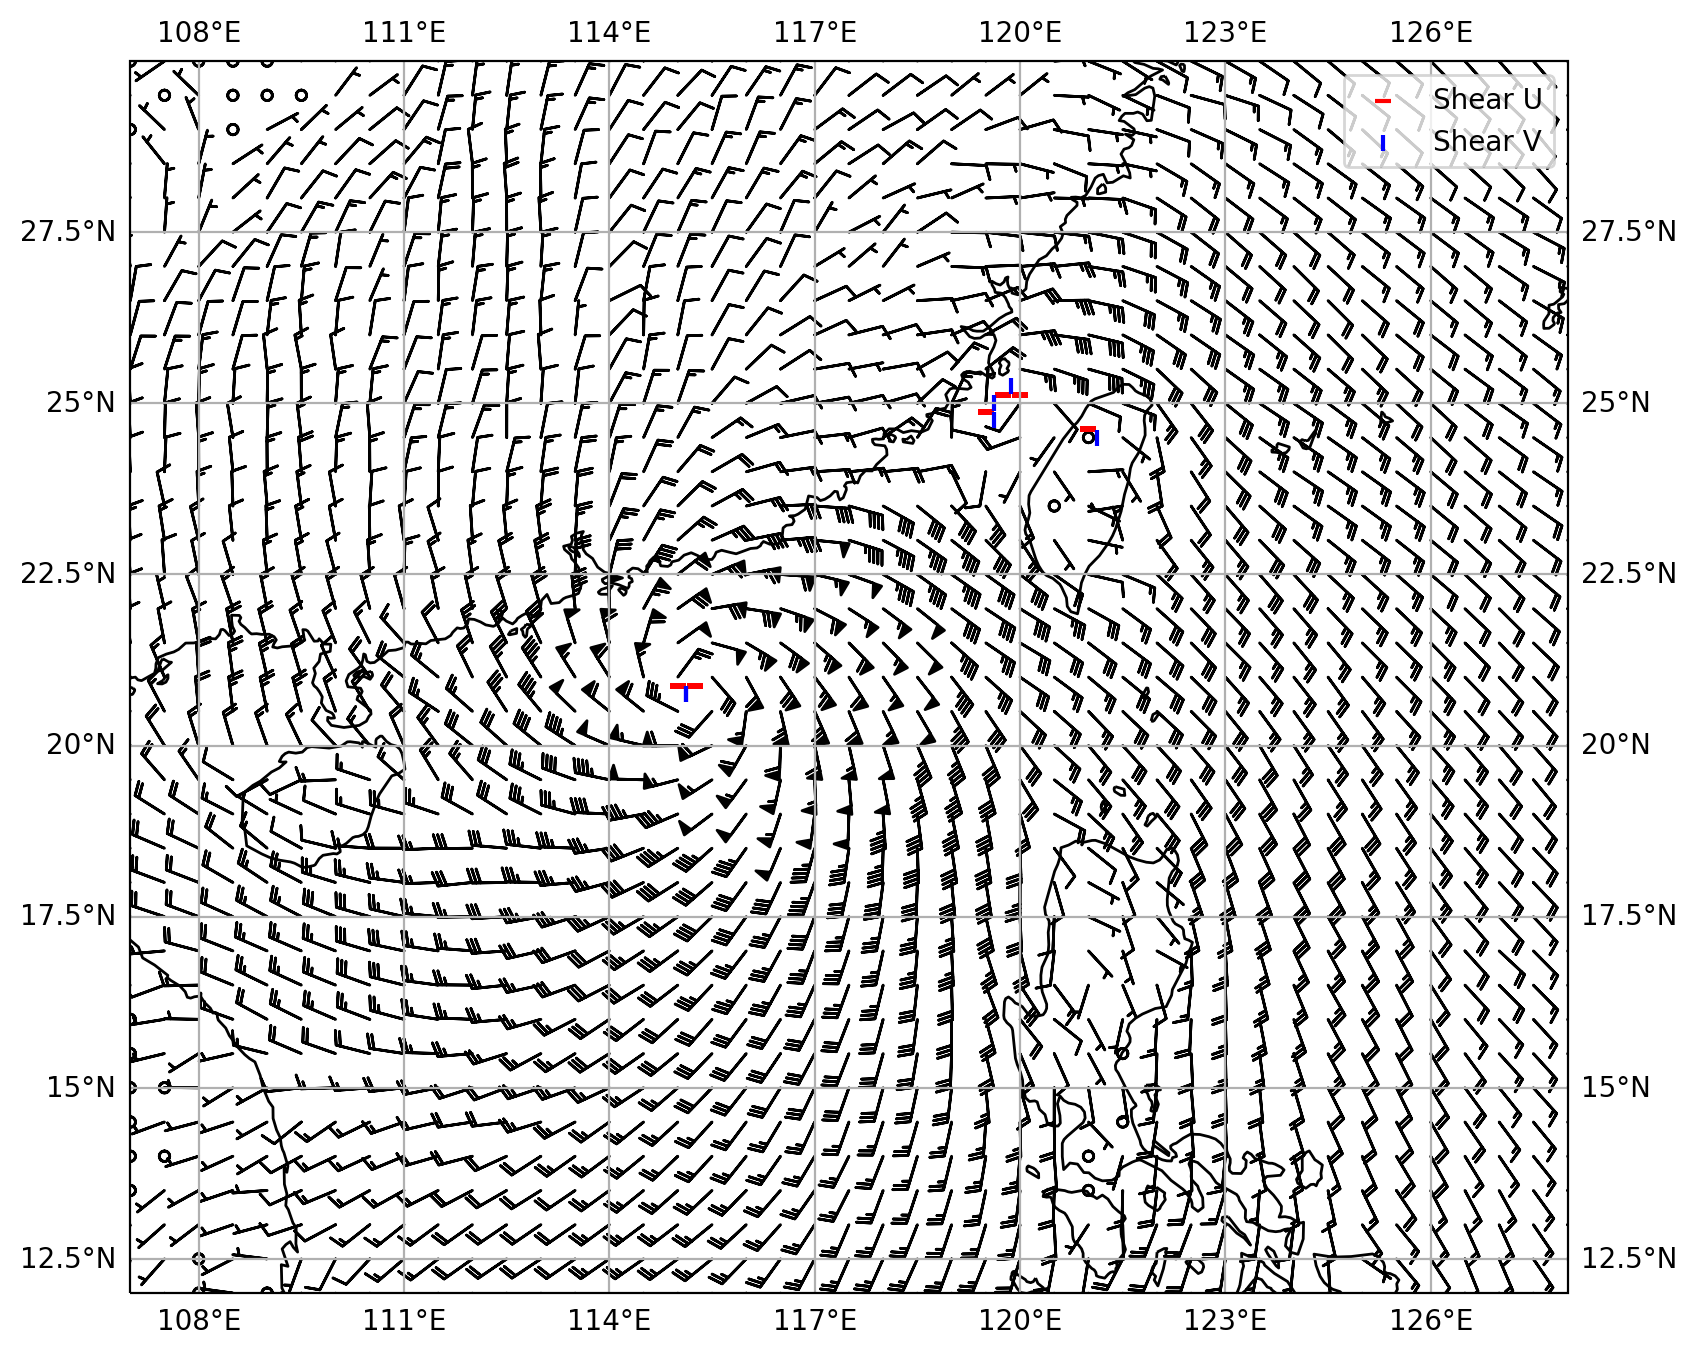

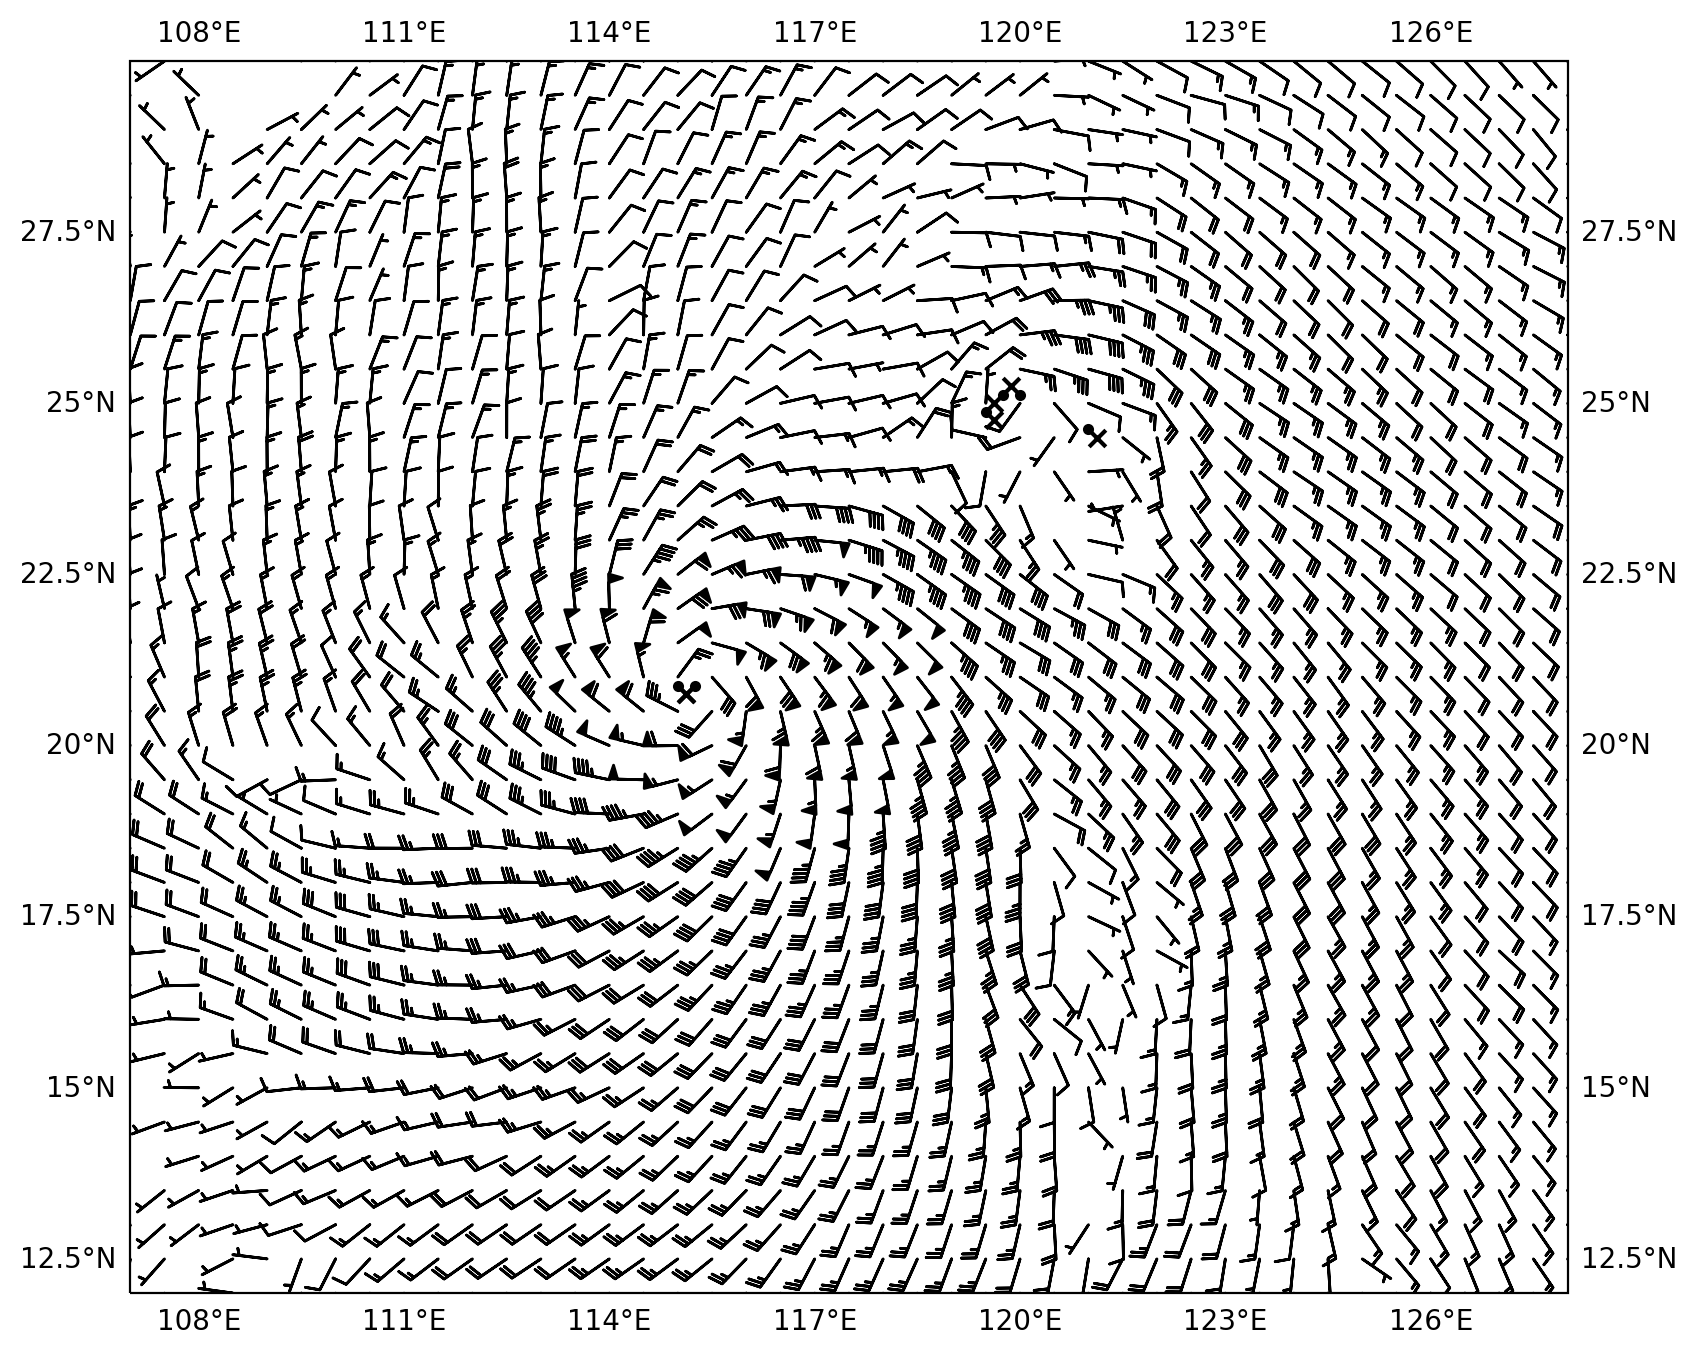

In [55]:
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},)

# 添加shear_u和shear_v散点图
ax.scatter(nearest_shear_u_positions[:, 1], nearest_shear_u_positions[:, 0], color='r', label='Shear U', transform=ccrs.PlateCarree(),marker="_")  # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.scatter(nearest_shear_v_positions[:, 1], nearest_shear_v_positions[:, 0], color='b', label='Shear V', transform=ccrs.PlateCarree(),marker="|") 
ax.gridlines(draw_labels=True)
ax.legend()  # 添加图例
plt.show()

###########################
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
# ax.scatter(nearest_shear_u_positions[:, 1], nearest_shear_u_positions[:, 0], color='r', label='Shear U', transform=ccrs.PlateCarree(),marker="_")  # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
# ax.scatter(nearest_shear_v_positions[:, 1], nearest_shear_v_positions[:, 0], color='b', label='Shear V', transform=ccrs.PlateCarree(),marker="|") 
ax.scatter(nearest_shear_u_positions[:, 1], nearest_shear_u_positions[:, 0], color='black', label='Shear U', transform=ccrs.PlateCarree(),marker=".")  # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.scatter(nearest_shear_v_positions[:, 1], nearest_shear_v_positions[:, 0], color='black', label='Shear V', transform=ccrs.PlateCarree(),marker="x") 
ax.gridlines(draw_labels=True,linewidth=0)
# ax.legend()  # 添加图例
plt.show()

Average positions:
 [[ 20.8125   115.125   ]
 [ 24.5625   121.0625  ]
 [ 25.020834 119.729164]]


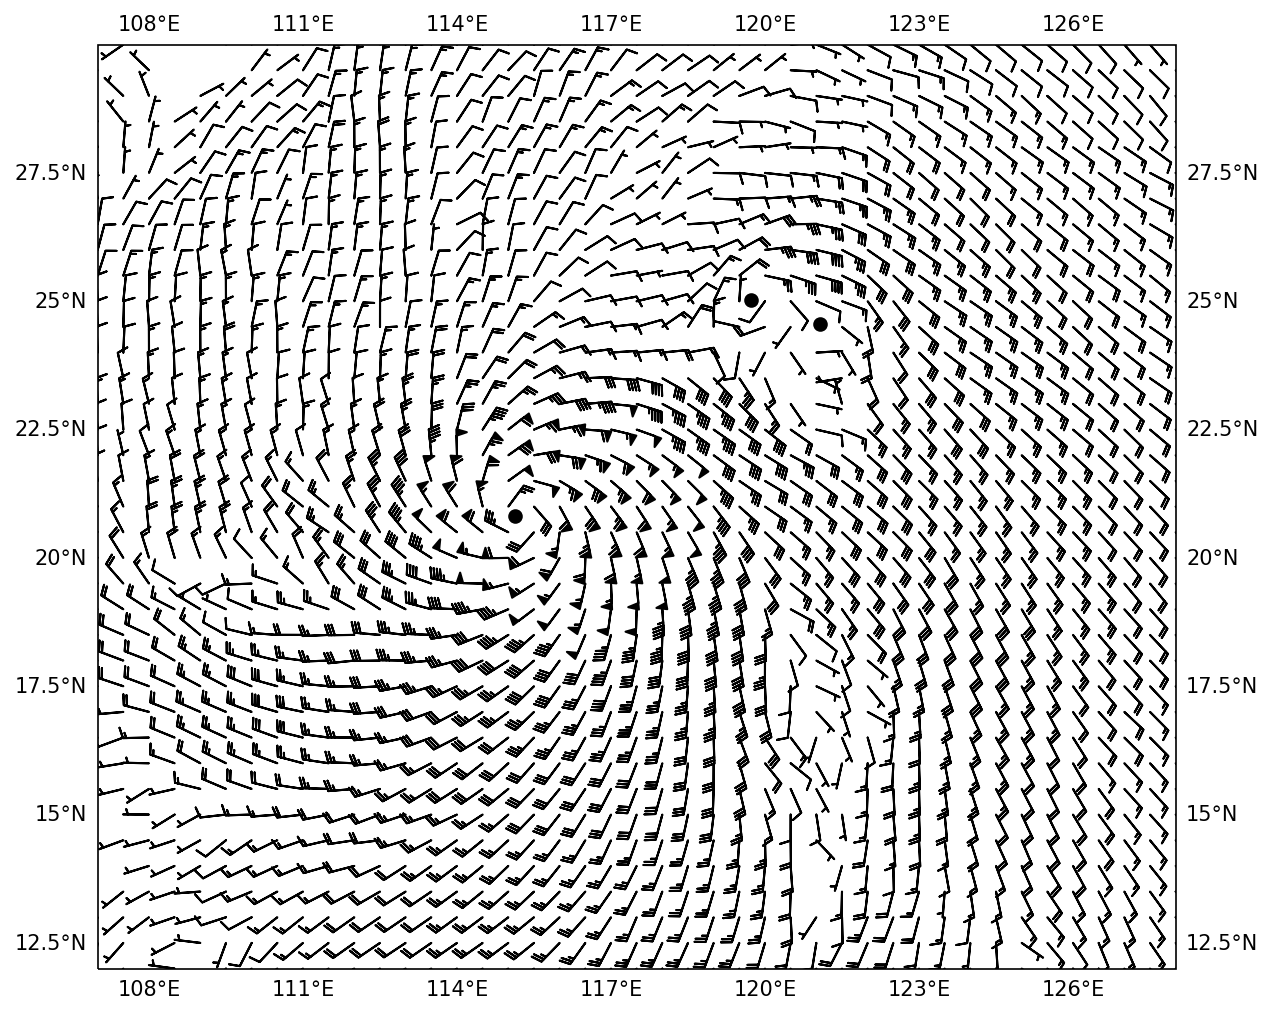

In [19]:
# 合并nearest_shear_u_positions和nearest_shear_v_positions为center_position
center_position = np.vstack([nearest_shear_u_positions, nearest_shear_v_positions])

# 使用DBSCAN进行聚类，eps和min_samples参数需要根据你的数据调整
clustering = DBSCAN(eps=gridUnit*2, min_samples=2).fit(center_position)

# 找到所有的类别（忽略-1，-1表示噪声点）
labels = set(clustering.labels_)
if -1 in labels:
    labels.remove(-1)

# 对每一组进行平均
average_positions = np.array([np.mean(center_position[clustering.labels_==label], axis=0) for label in labels])

print('Average positions:\n', average_positions)

# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
ax.scatter(average_positions[:, 1], average_positions[:, 0], color='black', label='shear center', transform=ccrs.PlateCarree())  # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.gridlines(draw_labels=True, linewidth=0)
# ax.legend()  # 添加图例
plt.show()

In [95]:
average_positions[:, 0]

array([20.8125  , 24.5625  , 25.020834], dtype=float32)

In [20]:
center_vor = np.empty(average_positions.shape[0])
print(center_vor)

[0. 1. 1.]


In [21]:
vorticity = mpcalc.vorticity(u10, v10)* 1e5
# 计算涡度，判断
for i, position in enumerate(average_positions):
    center_vor[i] = vorticity.sel(longitude=position[1], latitude=position[0], method="nearest")
print(center_vor)
# filter average_positions base on center_vor>20
# filter_position = average_positions.where(center_vor>20, drop=True)
# print(filter_position)

[69.26555866 -1.03232449 28.54119806]


In [22]:
# 根据涡度值筛选索引
# 阈值的英文单词
vor_threshold = 20
index = center_vor > vor_threshold

# 使用这个索引来筛选average_positions中的相应位置
filter_positions = average_positions[index]

# 对涡度进行同样的筛选
filter_vor = center_vor[index]

# 将筛选后的经纬度和涡度组合在一起
filter_center = np.hstack((filter_positions, filter_vor.reshape(-1,1)))

print(filter_center)# 经度，纬度，涡度

[[ 20.8125     115.125       69.26555866]
 [ 25.02083397 119.72916412  28.54119806]]


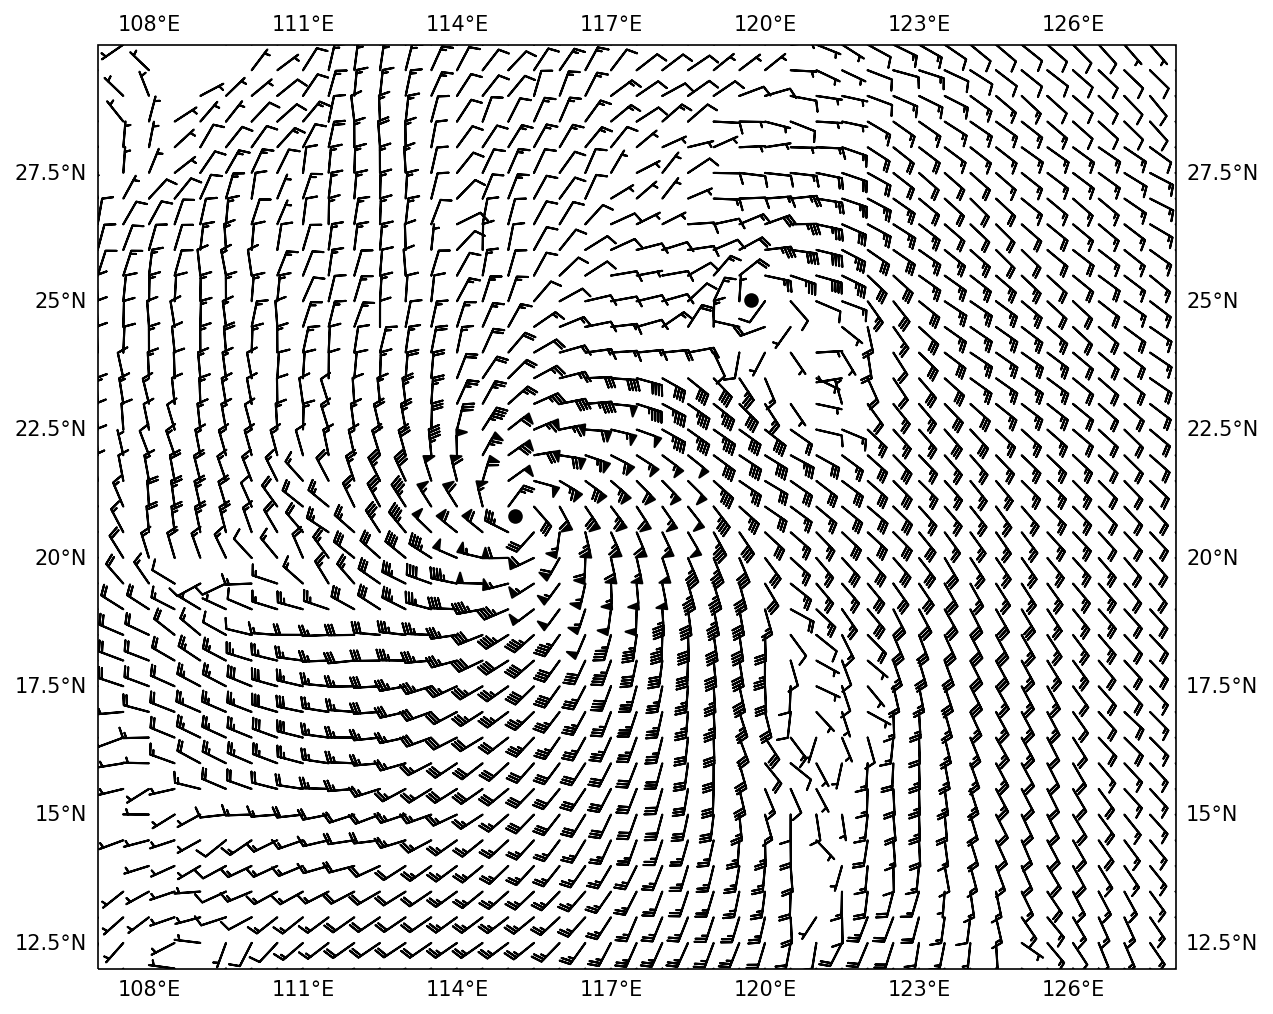

In [23]:
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(),
          length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
ax.scatter(filter_center[:, 1], filter_center[:, 0], color='black', label='shear center', transform=ccrs.PlateCarree())  # 注意这里我们使用了[:, 1]获取经度，[:, 0]获取纬度
ax.gridlines(draw_labels=True, linewidth=0)
# ax.legend()  # 添加图例
plt.show()

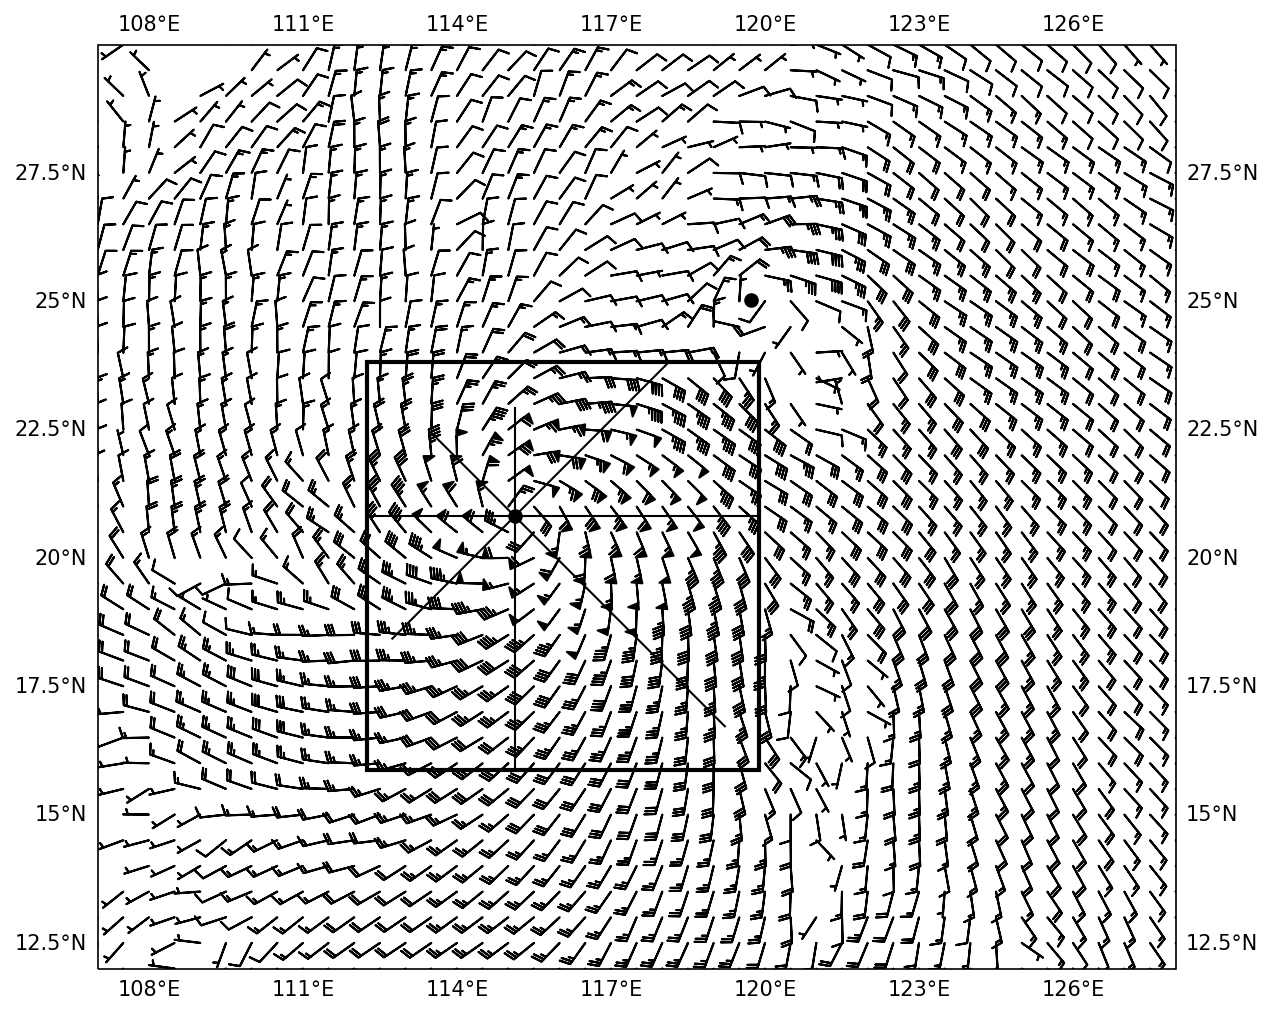

In [43]:
from matplotlib import patches

# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  

# 添加风向杆图
skip = 2  
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(),
          length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
ax.scatter(filter_center[:, 1], filter_center[:, 0], color='black', label='shear center', transform=ccrs.PlateCarree())

# 添加矩形框
rectangle = patches.Rectangle((bound_01[3], bound_01[1]), bound_01[2] - bound_01[3], bound_01[0] - bound_01[1],
                              linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
ax.add_patch(rectangle)

# 添加直线
p0 = [20.8125, 115.125]
center = [20.8125, 115.125]
p1 = [25.57440476190476, 115.125]
for i in range(4, 12):
  ax.plot([center[1], bound_01[i][1]], [center[0], bound_01[i][0]], color='black', linewidth=1, transform=ccrs.PlateCarree())  # 注意这里绘图时，x坐标（经度）在前，y坐标（纬度）在后


ax.gridlines(draw_labels=True, linewidth=0)
plt.show()


In [47]:
center02 = [25.02083397,119.72916412]
point_list_02 =  create_point_list(center02, 6)
# 循环point_list
tc_info_list02 = []
for line in point_list_02:
    # print(line)
    d_bound, d_r12, d_r17, d_vor0, R_max, R_min = get_tc_info(line)
    tc_info_list02.append([d_bound, d_r12, d_r17, d_vor0, R_max, R_min])
print(tc_info_list02)
tc_info02 = np.array(tc_info_list02)
bound_02 = calBound(tc_info02, center02)

The maximum value of u10_section is at distance 278.95287958115154
No such location found d_r17
The location where speed_section first drops below 12 with decreasing gradient is at distance 291.1570680628266km
The maximum value of u10_section is at distance 80.19895287958083
No such location found d_r17
No such location found d_r12
The maximum value of u10_section is at distance 108.09424083769613
No such location found d_r17
The location where speed_section first drops below 12 with decreasing gradient is at distance 116.81151832460732km
The maximum value of u10_section is at distance 59.27748691099494
No such location found d_r17
No such location found d_r12
The maximum value of u10_section is at distance 153.42408376963363
No such location found d_r17
The location where speed_section first drops below 12 with decreasing gradient is at distance 256.28795811518336km
The maximum value of u10_section is at distance 41.84293193717299
No such location found d_r17
No such location found d_

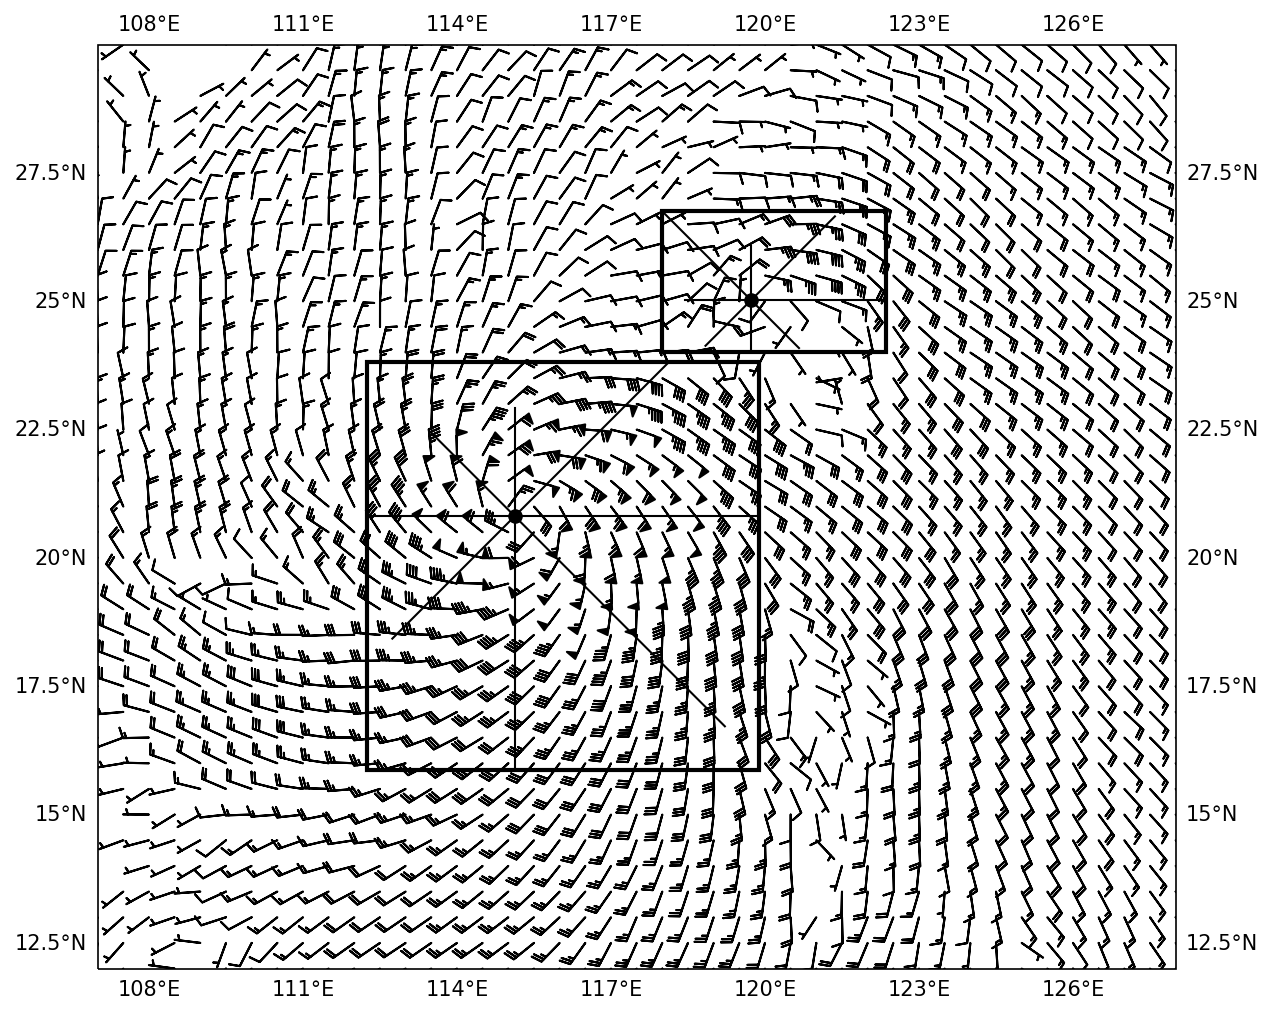

In [53]:


# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=150)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])  

# 添加风向杆图
skip = 2  
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(),
          length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})

# 添加shear_u和shear_v散点图
ax.scatter(filter_center[:, 1], filter_center[:, 0], color='black', label='shear center', transform=ccrs.PlateCarree())

# 添加矩形框
rectangle = patches.Rectangle((bound_02[3], bound_02[1]), bound_02[2] - bound_02[3], bound_02[0] - bound_02[1],
                              linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree(), )# linestyle
ax.add_patch(rectangle)

# 添加直线
p0 = [20.8125, 115.125]
center = [20.8125, 115.125]
p1 = [25.57440476190476, 115.125]
for i in range(4, 12):
  ax.plot([center02[1], bound_02[i][1]], [center02[0], bound_02[i][0]], color='black', linewidth=1, transform=ccrs.PlateCarree(), )  # 注意这里绘图时，x坐标（经度）在前，y坐标（纬度）在后

# 添加矩形框
rectangle = patches.Rectangle((bound_01[3], bound_01[1]), bound_01[2] - bound_01[3], bound_01[0] - bound_01[1],
                              linewidth=2, edgecolor='black', facecolor='none',  transform=ccrs.PlateCarree())
ax.add_patch(rectangle)

# 添加直线
# p0 = [20.8125, 115.125]
# center = [20.8125, 115.125]
# p1 = [25.57440476190476, 115.125]
for i in range(4, 12):
  ax.plot([center[1], bound_01[i][1]], [center[0], bound_01[i][0]], color='black', linewidth=1, transform=ccrs.PlateCarree())  # 注意这里绘图时，x坐标（经度）在前，y坐标（纬度）在后


ax.gridlines(draw_labels=True, linewidth=0)
plt.show()


No such location found
The location where speed_section first drops below 12 with decreasing gradient is at distance 256.55660377358464km
The maximum value of u10_section is at distance 153.584905660377, max speed is <xarray.DataArray ()>
array(16.44269753)
Coordinates:
    time     datetime64[ns] 2018-09-16


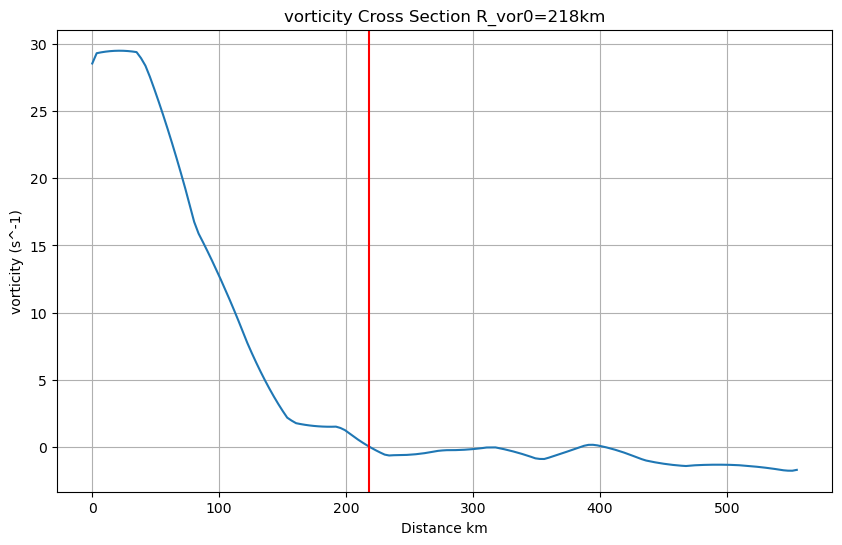

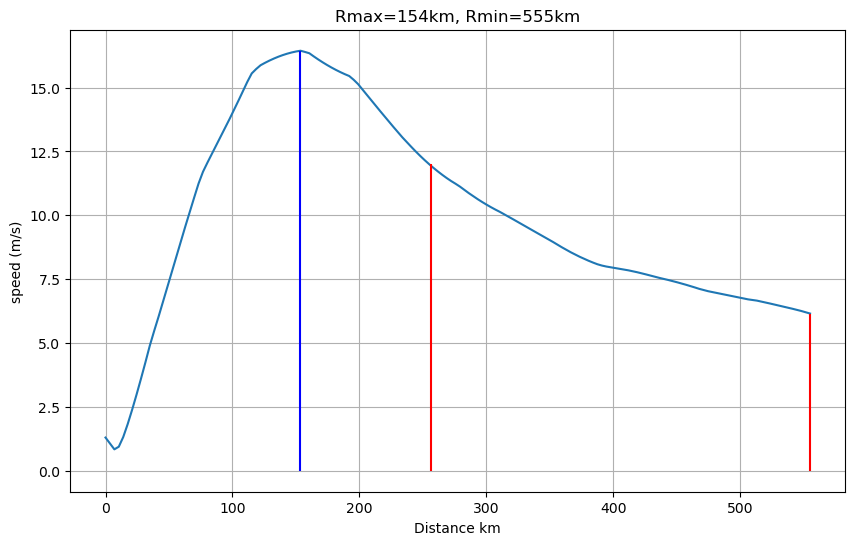

In [44]:
# ================从中心点开始插值==================#
# Define the points
p0 = center02
p1 = point_list_02[4][1]#[p0[0], p0[1]+8]

# Number of cross section points
n_points = int(np.sqrt((p1[1]-p0[1])**2 + (p1[0]-p0[0])**2)/gridUnit)*8

# Create a set of points along the path
lon_along_path = np.linspace(p0[1], p1[1], n_points)
lat_along_path = np.linspace(p0[0], p1[0], n_points)

# Create a new dataset with these coordinates
new_coords = xr.Dataset({"longitude": (["points"], lon_along_path), "latitude": (["points"], lat_along_path)})

# ================计算速度剖面==================#
u10_section = u10.interp(new_coords)
v10_section = v10.interp(new_coords)
speed_section = np.sqrt(u10_section**2 + v10_section**2)
# Create a distance array along the path
distance_along_path = np.sqrt(np.diff(lon_along_path)**2 + np.diff(lat_along_path)**2)
distance_along_path = np.insert(distance_along_path, 0, 0)  # insert 0 at the start
cumulative_distance = np.cumsum(distance_along_path)
cumulative_distance = cumulative_distance*111. # 纬度距离换算成公里

# Compute the gradient of u10_section
gradient_speed = np.gradient(speed_section)

# ================计算涡度阈值==================#
vorticity = mpcalc.vorticity(u10, v10)* 1e5
vor_section = vorticity.interp(new_coords)

d_vor0 = cumulative_distance[-1]
d_vor0_index = -1
# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if vor_section.values[i] < 0:
        d_vor0 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        d_vor0_index = i
        break

# ================计算速度最大阈值==================#
# Find the index of the maximum value
max_index = np.argmax(speed_section[:d_vor0_index].values)

# Find the distance corresponding to this index
R_max = cumulative_distance[max_index]

# ==============计算R_max 之后的极小值点==================#
R_min = cumulative_distance[-1]
R_min_index = -1
for i in range(max_index+1, len(speed_section.values)-1):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section[i-1]>speed_section[i] and speed_section[i+1]>speed_section[i]:
        R_min = cumulative_distance[i]
        R_min_index = i
        break

# ================计算速度阈值==================#
# Perform the interpolation along the path


# Initialize d_r12 as None, this will hold the distance if we find a suitable location
d_r12 = None
d_r17 = None

# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section.values[i-1] >= 17 and speed_section.values[i]<=17:
        d_r17 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        break
# Print the found location
if d_r17 is not None:
    print(f"The location where speed_section first drops below 17 with decreasing gradient is at distance {d_r17}km")
else:
    print("No such location found")

# Iterate over the speed_section
for i in range(1, len(speed_section.values)):
    # Check if the value is less than 12 and the gradient is decreasing
    if speed_section.values[i-1] >= 12 and speed_section.values[i]<=12:
        d_r12 = (cumulative_distance[i-1] + cumulative_distance[i])/2.0
        break

# Print the found location
if d_r12 is not None:
    print(f"The location where speed_section first drops below 12 with decreasing gradient is at distance {d_r12}km")
else:
    print("No such location found")


# Print the result
print(f"The maximum value of u10_section is at distance {R_max}, max speed is {np.max(speed_section)}")




plt.figure(figsize=(10,6))
plt.plot(cumulative_distance, vor_section.values)
if(d_vor0):
    plt.axvline(x = d_vor0,  color ='red')
plt.xlabel('Distance km')
plt.ylabel('vorticity (s^-1)')
plt.title(f'vorticity Cross Section R_vor0={d_vor0:.0f}km')
plt.grid(True)
plt.show()

# ================绘图==================#
# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative_distance, speed_section.values)
# plt.plot(cumulative_distance*111.1, gradient_speed)
# plt.vlines(d_r17, 0, 17, colors='orange', linestyles='solid',)
if d_r12:
    plt.vlines(d_r12, 0, 12, colors='red', linestyles='solid',)
# plt.vlines(d_r12, 0, 12, colors='red', linestyles='solid',)
plt.vlines(R_min, 0, speed_section[R_min_index], colors='red', linestyles='solid',)
plt.vlines(R_max, 0, speed_section[max_index], colors='blue', linestyles='solid',)
plt.xlabel('Distance km')
plt.ylabel('speed (m/s)')
# plt.title(f'wind speed Cross Section between p0 and p1')
# plt.title(f'Rmax={R_max:.0f}km, R17={d_r17:.0f}km, R12={d_r12:.0f}km')
plt.title(f'Rmax={R_max:.0f}km, Rmin={R_min:.0f}km')
plt.grid(True)
plt.show()




In [31]:
speed_section[max_index]

<xarray.DataArray ()>
array(7.16802993)
Coordinates:
    time       datetime64[ns] 2018-09-16
    longitude  float64 120.0
    latitude   float64 24.75

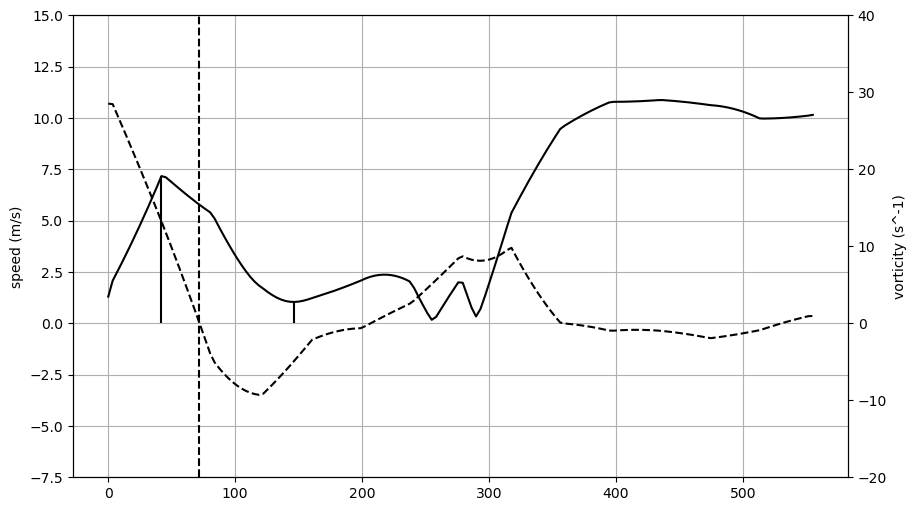

In [30]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot wind speed
ax1.plot(cumulative_distance, speed_section.values, 'k-')
# ax1.vlines(d_r17, 0, 17, colors='k', linestyles='solid',)
# ax1.vlines(d_r12, 0, 12, colors='k', linestyles='solid',)
ax1.vlines(R_max, 0, speed_section[max_index], colors='k', linestyles='solid',)
ax1.vlines(R_min, 0, speed_section[R_min_index], colors='k', linestyles='solid',)
ax1.set_ylabel('speed (m/s)', color='k')
for tl in ax1.get_yticklabels():
    tl.set_color('k')
ax1.set_ylim(-7.5, 15)  # set the y-axis range

# Create a second y-axis that shares the x-axis
ax2 = ax1.twinx()

# Plot vorticity
ax2.plot(cumulative_distance, vor_section.values, 'k--')  # set line to dashed
ax2.axvline(x = d_vor0,  color ='k', linestyle='--')  # set line to dashed
ax2.set_xlabel('Distance km')
ax2.set_ylabel('vorticity (s^-1)', color='k')
# ax2.set_title(f'vorticity Cross Section R_vor0={d_vor0:.0f}km / wind speed Cross Section Rmax={R_max:.0f}km, R17={d_r17:.0f}km, R12={d_r12:.0f}km')
for tl in ax2.get_yticklabels():
    tl.set_color('k')
ax2.set_ylim(-20, 40)  # set the y-axis range

ax1.grid(True)
plt.savefig('径向距离vs风速和涡度_弱台风版.pdf', format='pdf')
plt.show()

In [75]:
# 计算中心附近最大风速
radi_bound = 2
for i, position in enumerate(filter_center[:,0:2]):
    v10_around = ds['v10'][0,:,:].sel(latitude=slice(position[0]+radi_bound, position[0]-radi_bound), longitude=slice(position[1]-radi_bound, position[1]+radi_bound))
    u10_around = ds['u10'][0,:,:].sel(latitude=slice(position[0]+radi_bound, position[0]-radi_bound), longitude=slice(position[1]-radi_bound, position[1]+radi_bound))
    # 计算风速大小
    wind_speed = np.sqrt(v10_around**2 + u10_around**2)
    # 找到最大风速的位置
    # max_position = np.where(wind_speed == wind_speed.max())
    print(wind_speed.max())
# print(wind_speed)

<xarray.DataArray ()>
array(29.088144, dtype=float32)
Coordinates:
    time     datetime64[ns] 2018-09-16
<xarray.DataArray ()>
array(17.354069, dtype=float32)
Coordinates:
    time     datetime64[ns] 2018-09-16


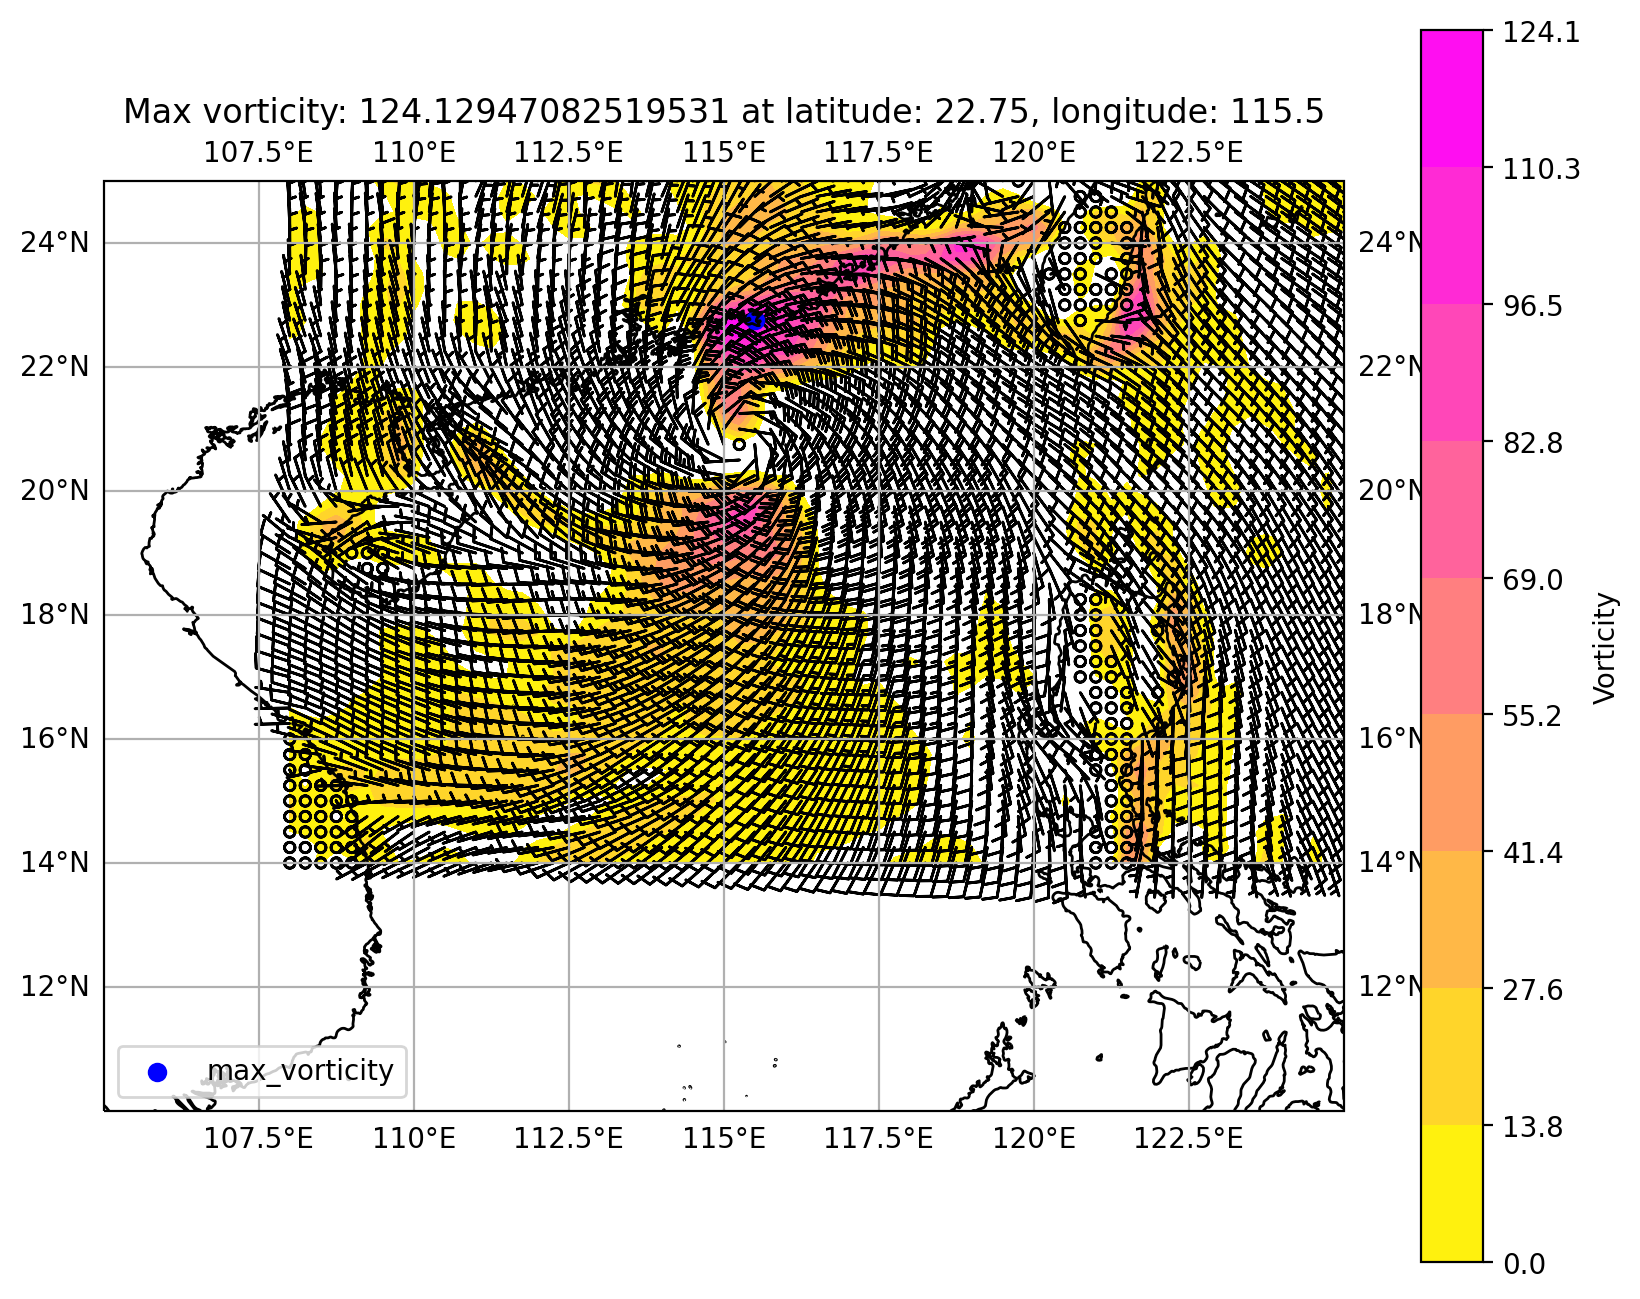

Max vorticity: 124.12947082519531 at latitude: <xarray.DataArray 'latitude' ()>
array(22.75, dtype=float32)
Coordinates:
    latitude  float32 22.75
    time      datetime64[ns] 2018-09-16
Attributes:
    units:      degrees_north
    long_name:  latitude, longitude: <xarray.DataArray 'longitude' ()>
array(115.5, dtype=float32)
Coordinates:
    longitude  float32 115.5
    time       datetime64[ns] 2018-09-16
Attributes:
    units:      degrees_east
    long_name:  longitude


In [76]:
# 计算涡度
v_grad = np.gradient(v10, gridUnit, axis=1)  # dv/dx
u_grad = np.gradient(u10, gridUnit, axis=0)  # du/dy
vorticity = v_grad/gridUnit + u_grad/gridUnit# 由于纬度反向变成加号
vorticity = vorticity
# 找到涡度最大值及其对应的经纬度
max_vorticity = np.max(vorticity)
max_position = np.unravel_index(np.argmax(vorticity), vorticity.shape)
max_latitude = latitude[max_position[0]]
max_longitude = longitude[max_position[1]]

# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([112.5, 120, 18, 24])
ax.set_extent([105, 125, 10, 25])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
  # 绘制涡度场

levels = np.linspace(0, np.max(vorticity), 10)
cf = ax.contourf(longitude, latitude, vorticity, levels=levels, transform=ccrs.PlateCarree(), cmap='spring_r')
plt.colorbar(cf, ax=ax, label='Vorticity')

# 添加风向杆图
skip = 1  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5)

# 绘制涡度最大值的位置
ax.scatter(max_longitude, max_latitude, color='blue', label="max_vorticity")
ax.gridlines(draw_labels=True)
ax.legend()  # 添加图例
# 设置titile
plt.title(f"Max vorticity: {max_vorticity} at latitude: {max_latitude.values}, longitude: {max_longitude.values}")
plt.show()
print(f"Max vorticity: {max_vorticity} at latitude: {max_latitude}, longitude: {max_longitude}")

In [20]:
v_grad = np.gradient(v10, gridUnit, axis=0)  # dv/dx
u_grad = np.gradient(u10, gridUnit, axis=1)  # du/dy
vorticity = v_grad - u_grad
print(vorticity)

[[ 1.1757245e+00  1.6942174e+00 -1.1910439e-02 ... -7.3685074e-01
  -1.1767292e+00 -1.4910297e+00]
 [ 1.3385074e+00  9.3988085e-01  1.4725900e-01 ... -4.4752026e-01
  -7.7491760e-01 -1.1129036e+00]
 [ 2.7050378e+00  1.9911284e+00  3.8818741e-01 ... -2.5673485e-01
  -4.9589539e-01 -1.1798601e+00]
 ...
 [ 5.6540966e-03 -4.1118503e-01  2.3265862e-01 ... -1.2858121e+00
  -6.5902376e-01  1.1412966e-01]
 [ 3.3431580e+00  1.3174367e+00  2.7441096e-01 ...  9.8080635e-03
  -1.1840703e+00 -1.1144733e+00]
 [ 1.1237034e+01  6.5484166e+00  9.6827841e-01 ...  3.7771082e-01
  -1.2951670e+00 -2.0504117e+00]]


In [19]:
vorticity

Magnitude,[[1.4345275679323024 1.3457667175482348 1.7960188990103516 ... -0.3576552093439509 -0.47772067485346725 -0.480224223351928] [3.9691768559417975 1.9996590669988046 -0.004629113788325739 ... -0.33183172388081644 -0.4511769497059345 -0.5025839476506809] [2.8978533216342646 0.8663131505860199 -0.9732929160784318 ... -0.4824548049783608 -0.19327270009706624 -0.3322688833213769] ... [4.344292768350998 2.5522481367506793 1.1966630873158042 ... -3.7751619900454894 -4.27312355304058 -2.889784704970947] [6.156470824079905 1.9990072934673535 -0.07509184013521582 ... -2.5176938855205346 -3.181836777887958 -1.954643898469407] [7.2983625021677465 0.6537085534491194 -2.0677059109536504 ... -0.8539152170240293 -1.8366698453290007 -2.169752389589072]]
Units,1/second


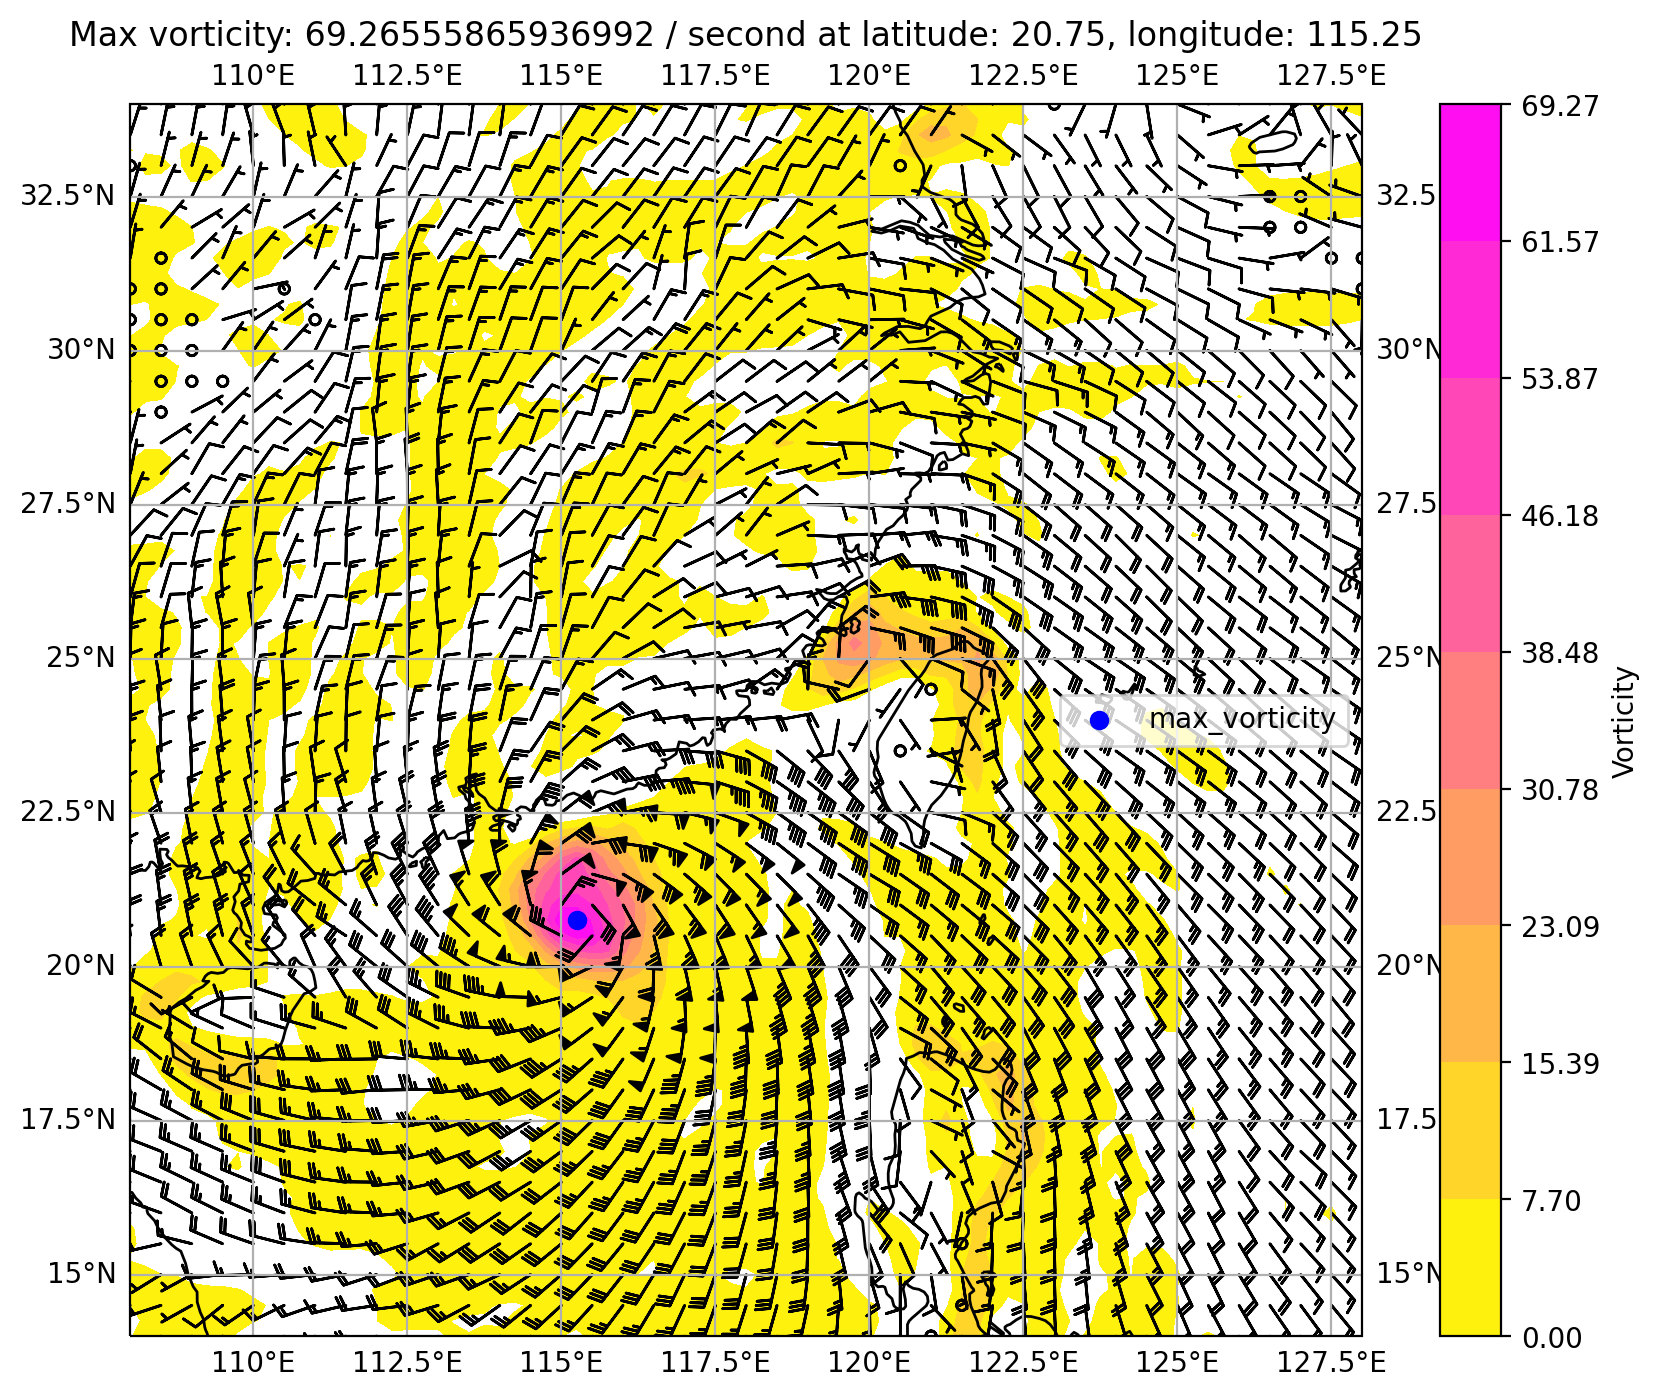

Max vorticity: 69.26555865936992 / second at latitude: 20.75, longitude: 115.25


In [77]:
vorticity = mpcalc.vorticity(u10, v10)* 1e5

# 找到涡度最大值及其对应的经纬度
max_vorticity = np.max(vorticity)
max_position = np.unravel_index(np.argmax(vorticity.values), vorticity.shape)
max_latitude = latitude[max_position[0]]
max_longitude = longitude[max_position[1]]

# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([112.5, 120, 18, 24])#ax.set_extent([105, 125, 10, 25])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
ax.set_extent([lon_range[0], lon_range[1], lat_range[1], lat_range[0]])
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# 绘制涡度场

levels = np.linspace(0, np.max(vorticity), 10)
cf = ax.contourf(longitude, latitude, vorticity, levels=levels, transform=ccrs.PlateCarree(), cmap='spring_r')
plt.colorbar(cf, ax=ax, label='Vorticity')

# 添加风向杆图
skip = 2  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], 
        transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20})

# 绘制涡度最大值的位置
ax.scatter(max_longitude, max_latitude, color='blue', label="max_vorticity")
ax.gridlines(draw_labels=True)
ax.legend()  # 添加图例
# 设置titile
plt.title(f"Max vorticity: {max_vorticity.item()} at latitude: {max_latitude.values}, longitude: {max_longitude.values}")
plt.show()
print(f"Max vorticity: {max_vorticity.item()} at latitude: {max_latitude.values}, longitude: {max_longitude.values}")

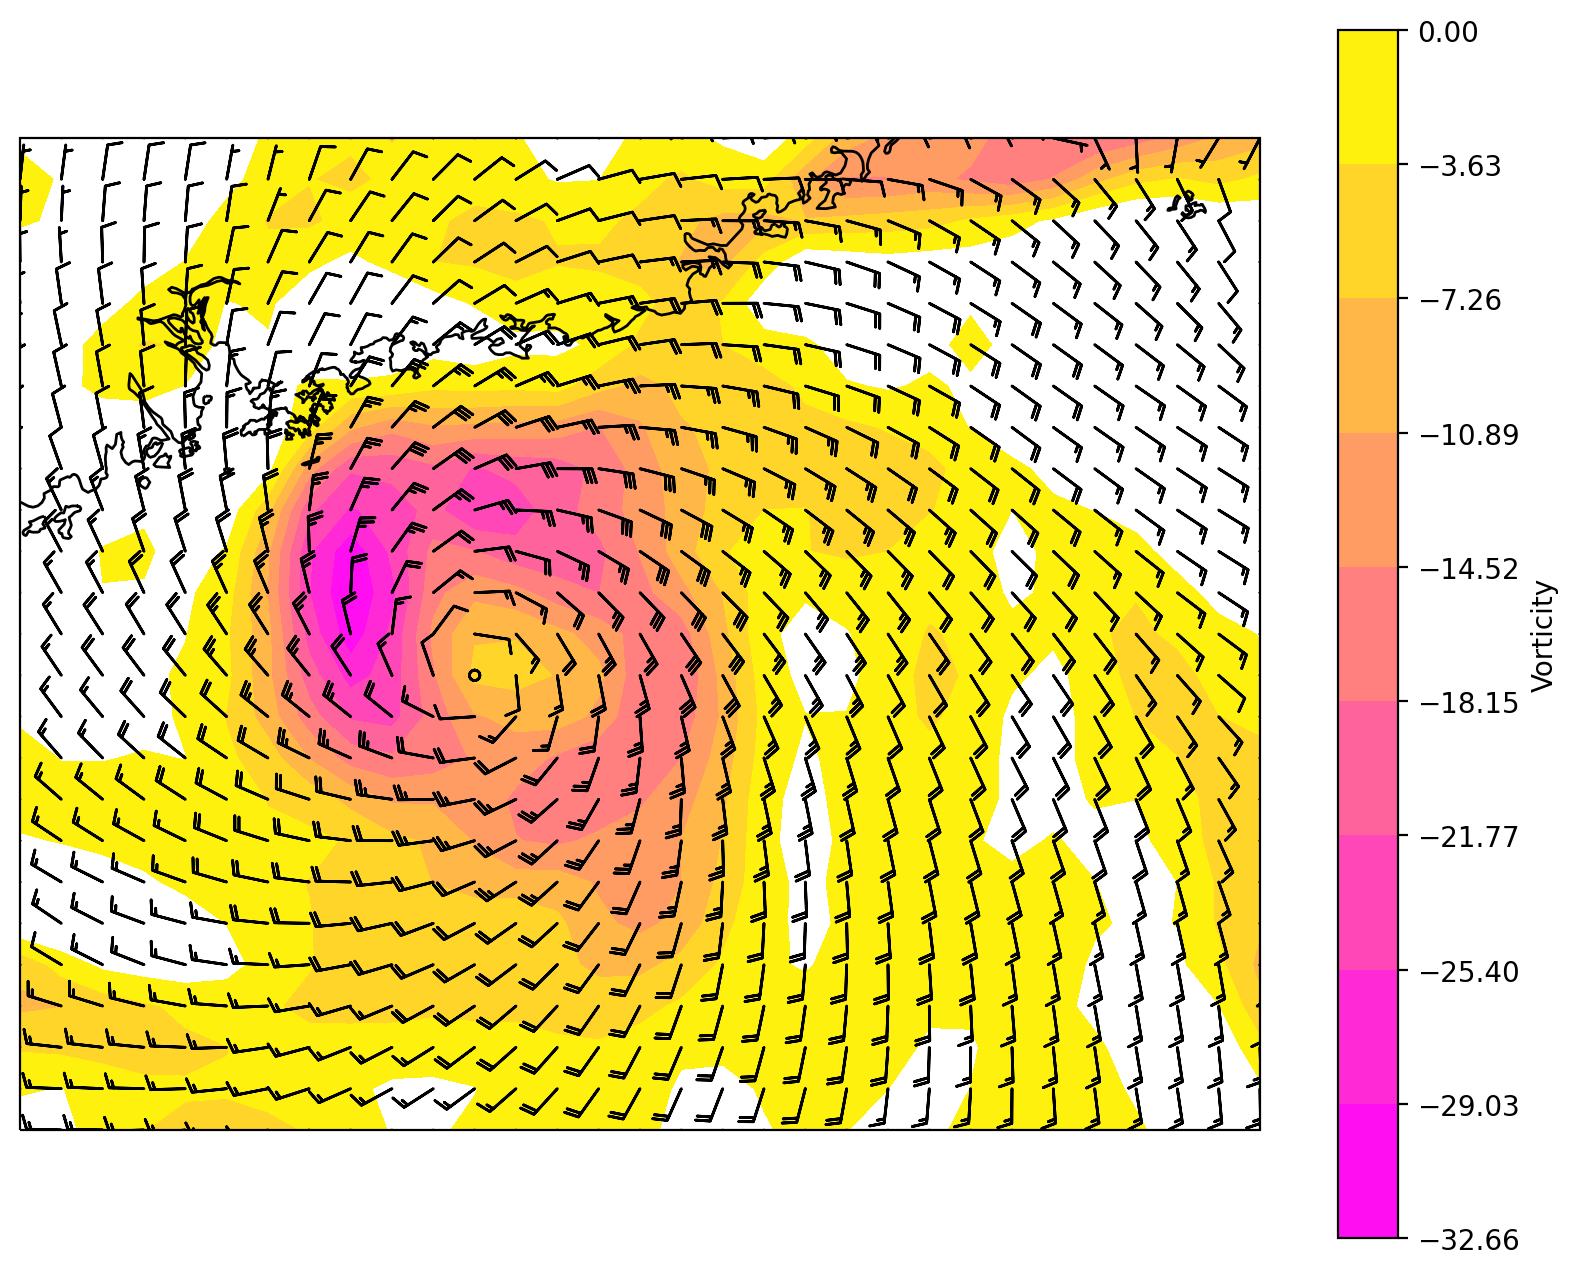

In [36]:

# Calculate the total deformation of the flow
div = mpcalc.divergence(u10, v10) * 1e5
# 创建地图
fig = plt.figure(figsize=(10, 8),dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([112.5, 120, 18, 24])#ax.set_extent([105, 125, 10, 25])  # 设置地图显示范围，格式为[longitude_min, longitude_max, latitude_min, latitude_max]
ax.add_feature(cfeature.COASTLINE)

# 绘制散度场

levels = np.linspace(np.min(div), 0, 10)
cf = ax.contourf(longitude, latitude, div, levels=levels, transform=ccrs.PlateCarree(), cmap='spring')
plt.colorbar(cf, ax=ax, label='divergence')

# 添加风向杆图
skip = 1  # 略过的网格数量
ax.barbs(longitude[::skip], latitude[::skip], u10[::skip,::skip], v10[::skip,::skip], transform=ccrs.PlateCarree(), length=5)

# 绘制涡度最大值的位置
# ax.scatter(max_longitude, max_latitude, color='blue', label="max_vorticity")
# ax.gridlines(draw_labels=True)
# ax.legend()  # 添加图例
# 设置titile
# plt.title(f"Max vorticity: {max_vorticity.item()} at latitude: {max_latitude.values}, longitude: {max_longitude.values}")
plt.show()
# print(f"Max vorticity: {max_vorticity.item()} at latitude: {max_latitude.values}, longitude: {max_longitude.values}")
